<a href="https://www.kaggle.com/code/omborse771924/ecommerce-sales-dataset-eda-feature-engineering?scriptVersionId=334049913" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abbas829/ecommerce-sales-dataset/ecommerce_sales_analytics_5000.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/abbas829/ecommerce-sales-dataset/ecommerce_sales_analytics_5000.csv')

In [3]:
df.info

<bound method DataFrame.info of       order_id order_date  customer_id product_category region  quantity  \
0        10001   1/1/2022         1102           Beauty  South         7   
1        10002   1/2/2022         1435         Clothing  South         7   
2        10003   1/3/2022         1860           Beauty   East         3   
3        10004   1/4/2022         1270      Electronics   West         5   
4        10005   1/5/2022         1106         Clothing   West         5   
...        ...        ...          ...              ...    ...       ...   
4995     14996   9/5/2035         1289         Clothing   West         2   
4996     14997   9/6/2035         1294           Beauty  North         3   
4997     14998   9/7/2035         1450           Beauty   West         3   
4998     14999   9/8/2035         1903      Electronics  South         4   
4999     15000   9/9/2035         1214             Home   East         7   

      unit_price  discount payment_method  delivery_day

In [4]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [5]:
df.tail()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38
4999,15000,9/9/2035,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90


In [6]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [7]:
df.isnull()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

## EDA

DATASET SHAPE
(5000, 12)
FIRST 5 ROWS
   order_id order_date  customer_id product_category region  quantity  \
0     10001   1/1/2022         1102           Beauty  South         7   
1     10002   1/2/2022         1435         Clothing  South         7   
2     10003   1/3/2022         1860           Beauty   East         3   
3     10004   1/4/2022         1270      Electronics   West         5   
4     10005   1/5/2022         1106         Clothing   West         5   

   unit_price  discount payment_method  delivery_days  customer_rating  \
0      373.65      0.28         Wallet             10              4.7   
1       47.74      0.09           Card              6              3.9   
2      311.28      0.31            COD              6              2.5   
3      524.47      0.02         Wallet              6              1.6   
4      139.87      0.33         Wallet              4              4.9   

   revenue  
0  1883.20  
1   304.10  
2   644.35  
3  2569.90  
4   468.56  


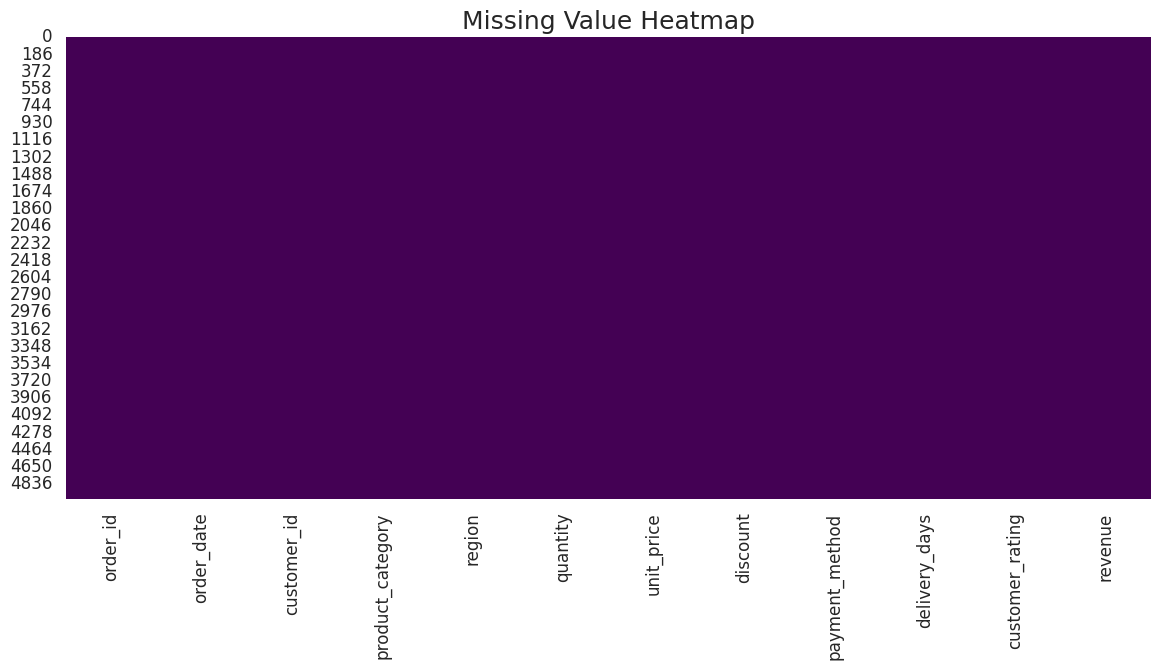


Numerical Columns
Index(['order_id', 'customer_id', 'quantity', 'unit_price', 'discount',
       'delivery_days', 'customer_rating', 'revenue'],
      dtype='object')

Categorical Columns
Index(['product_category', 'region', 'payment_method'], dtype='object')


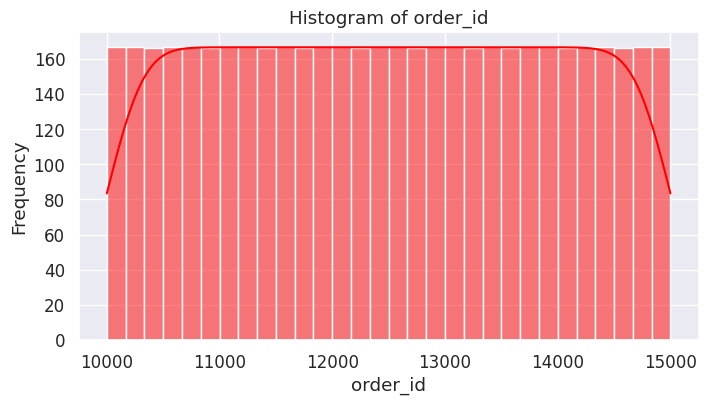

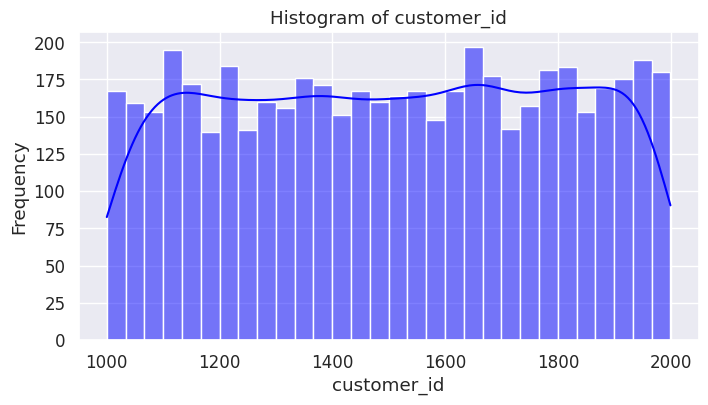

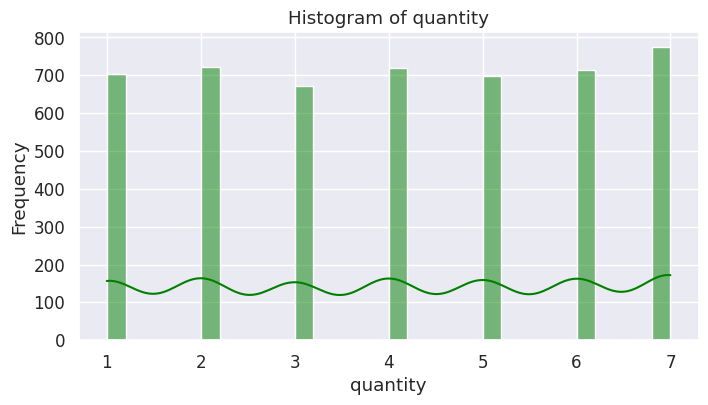

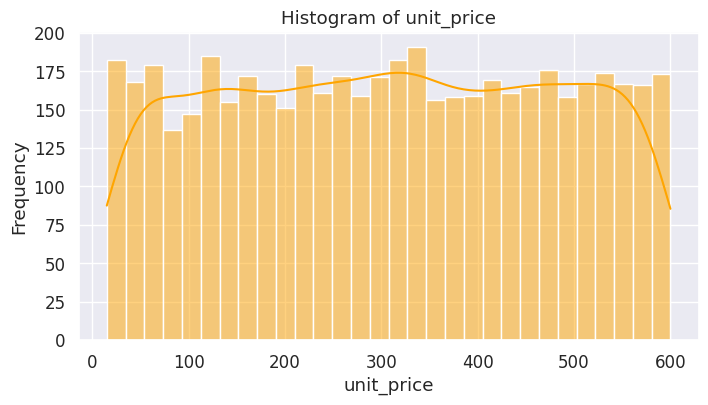

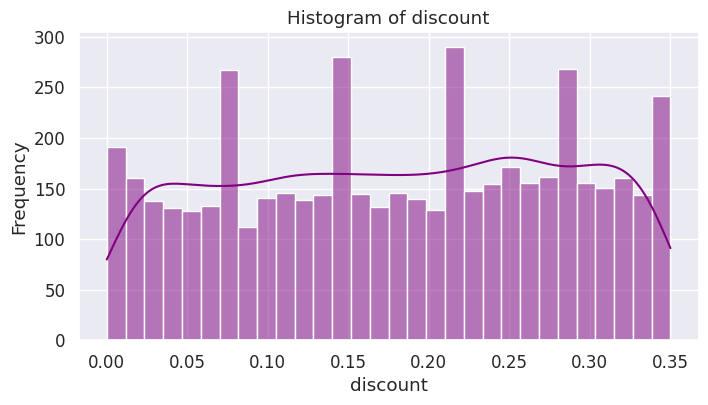

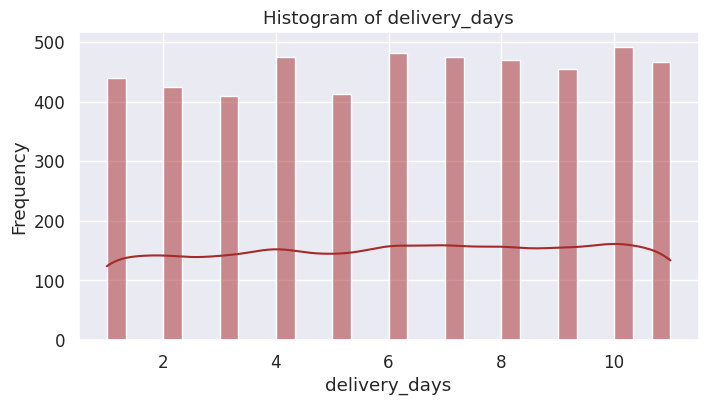

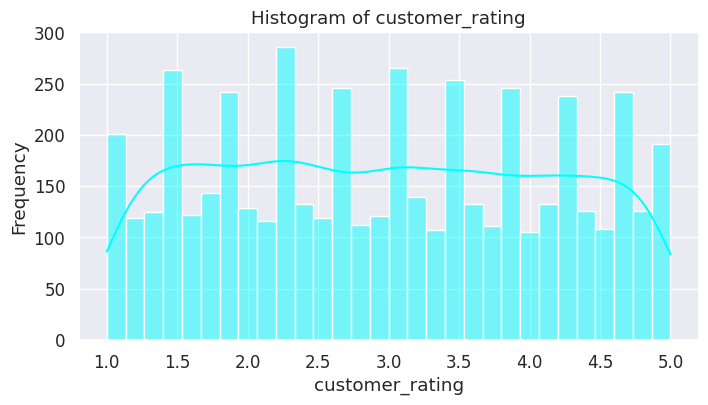

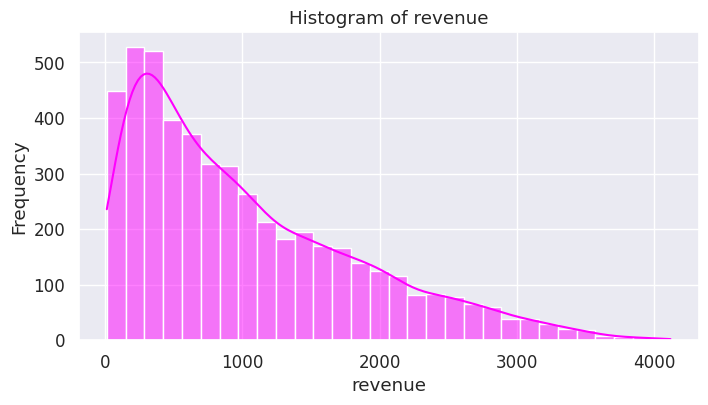

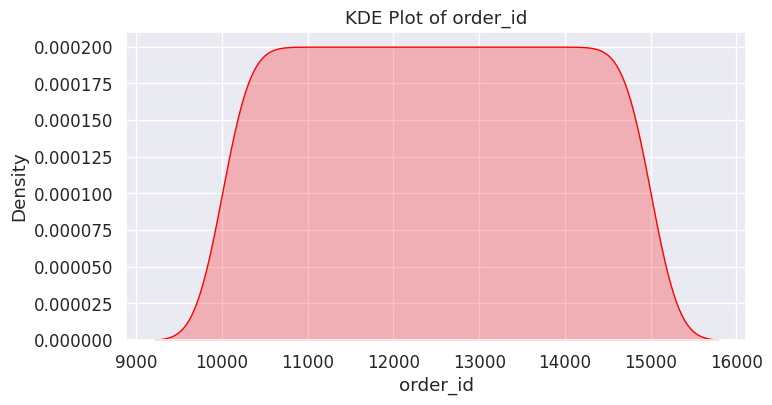

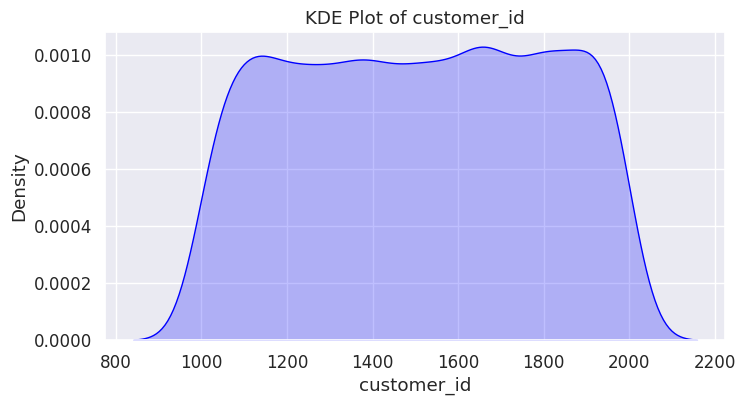

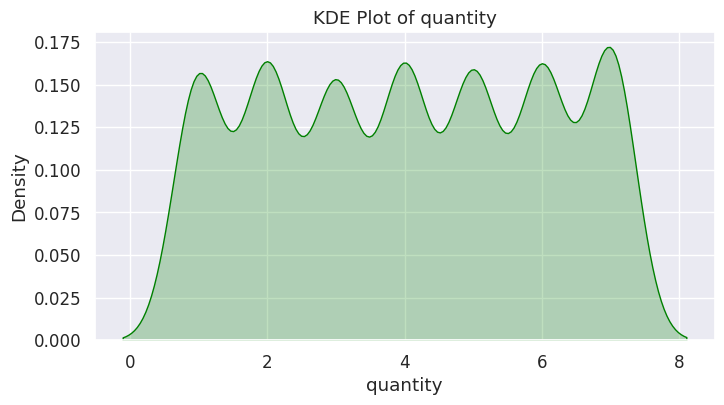

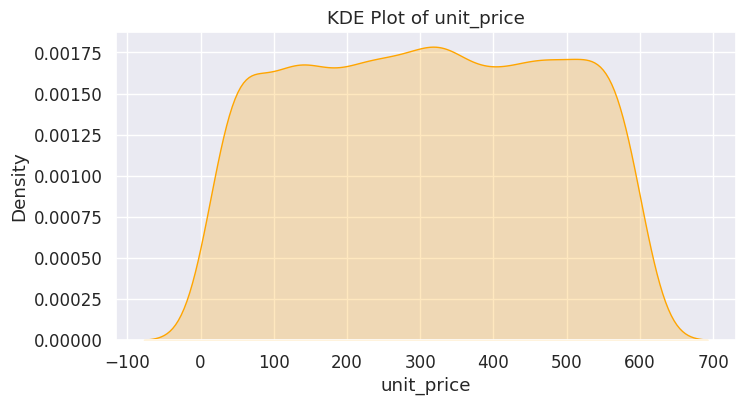

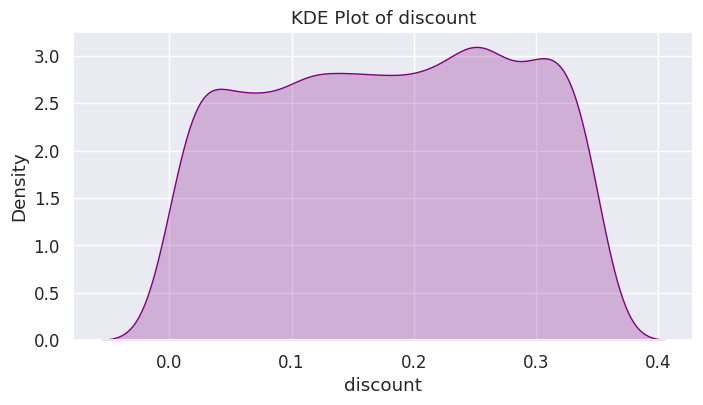

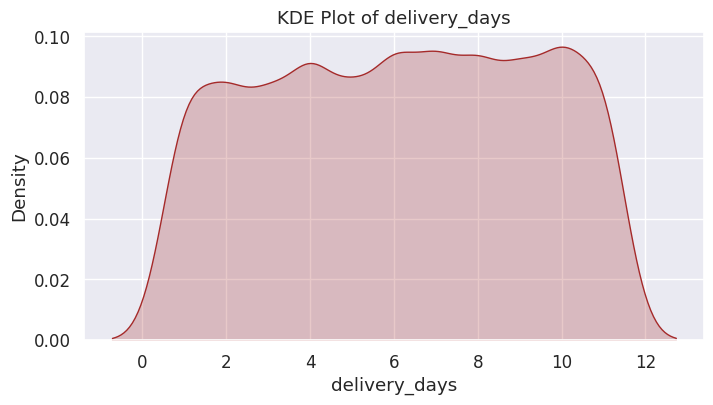

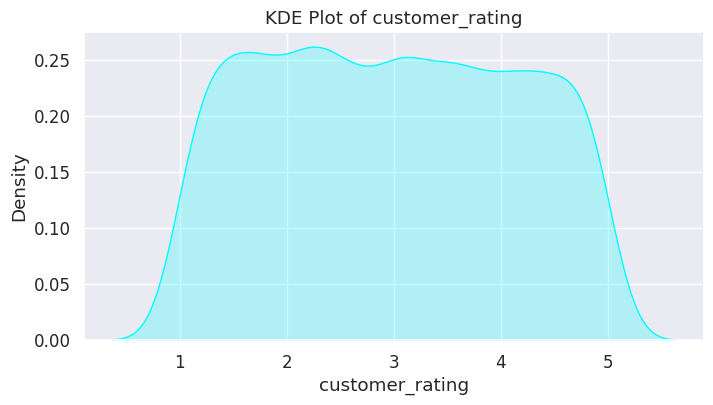

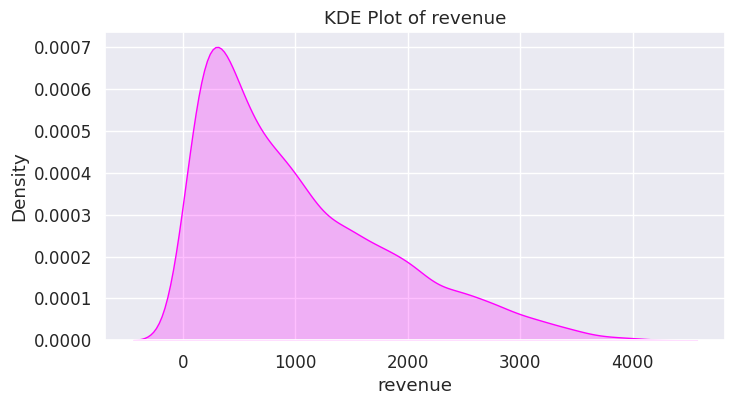

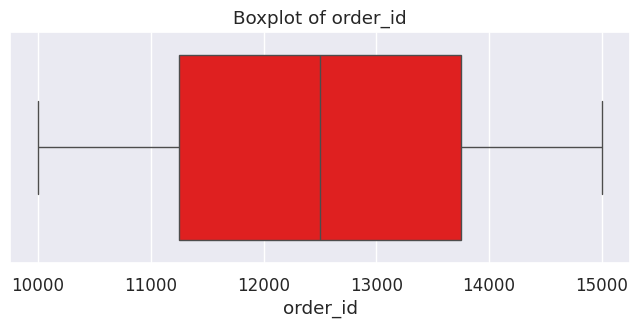

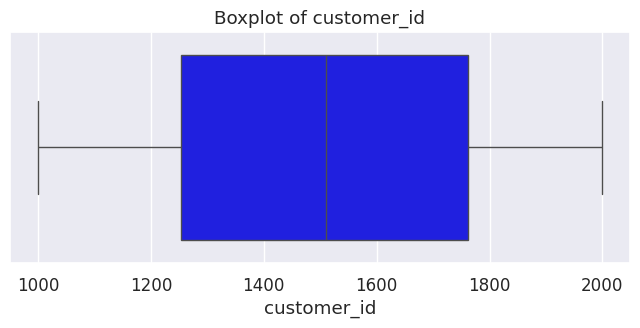

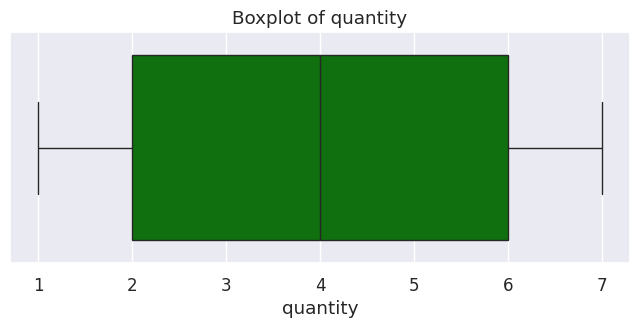

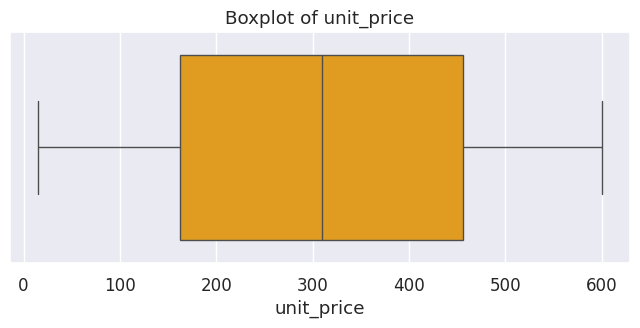

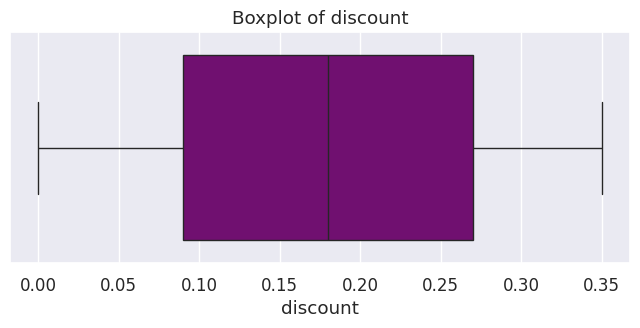

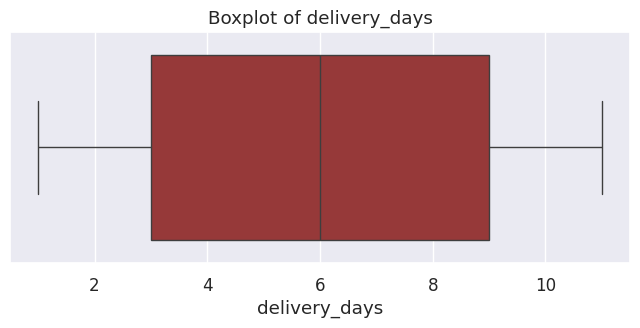

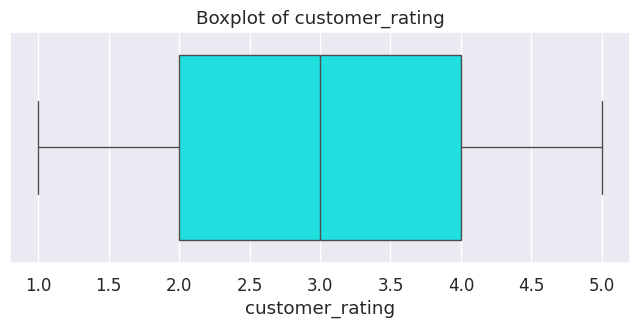

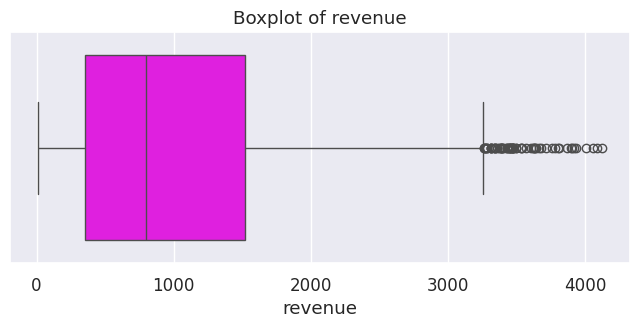

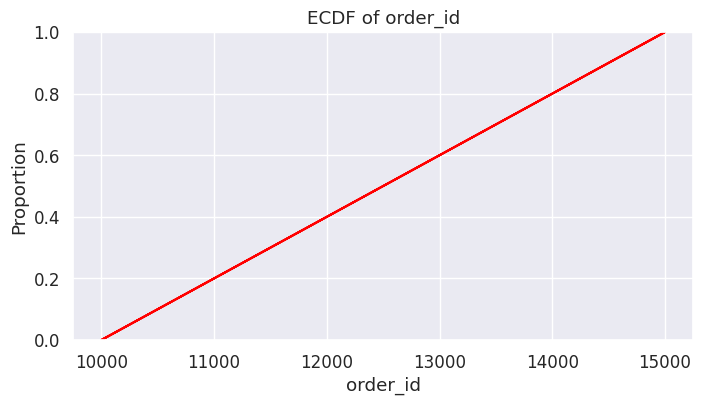

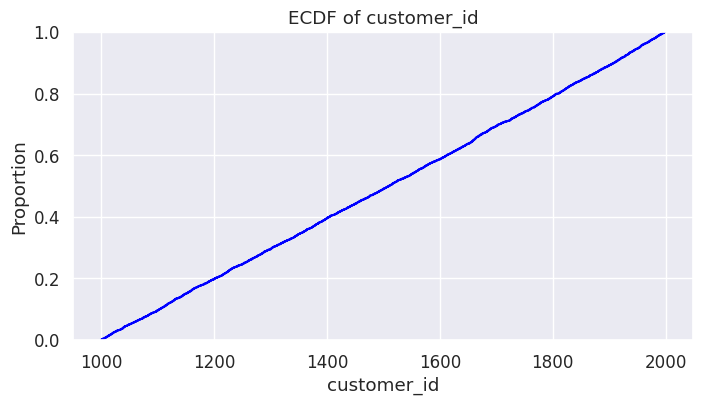

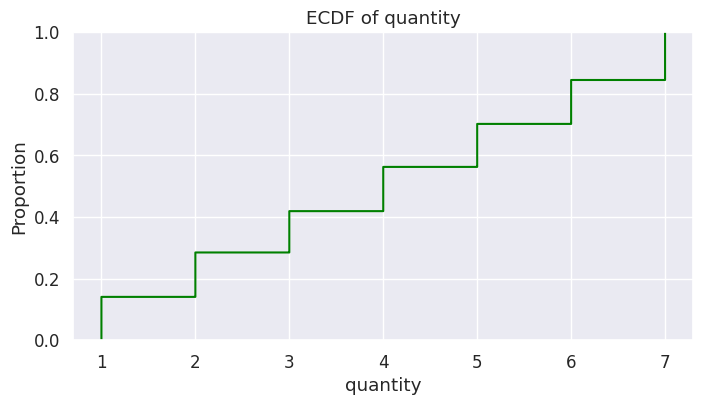

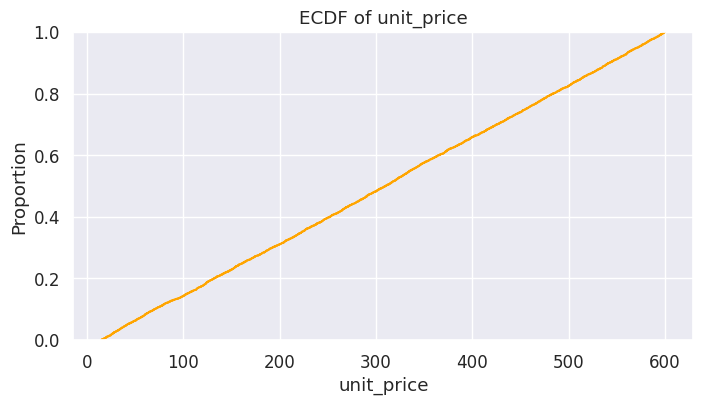

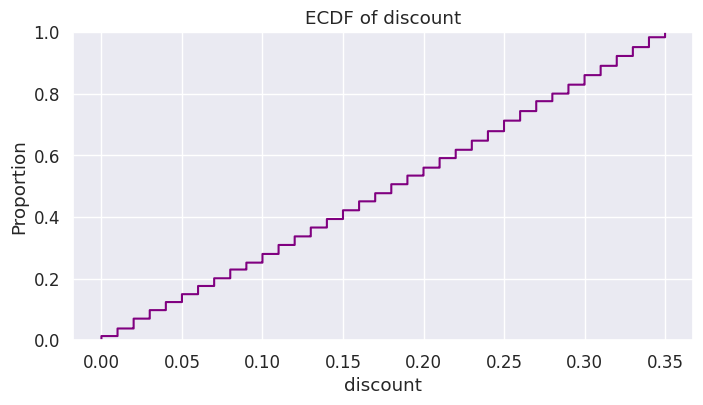

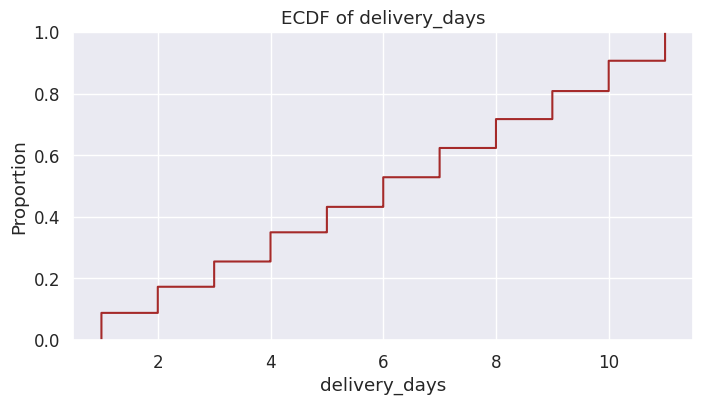

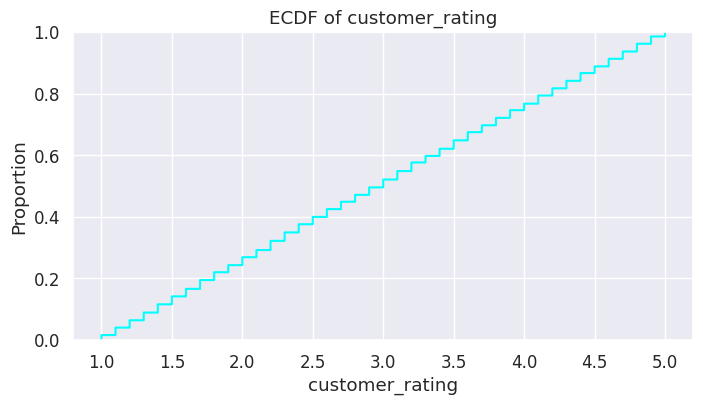

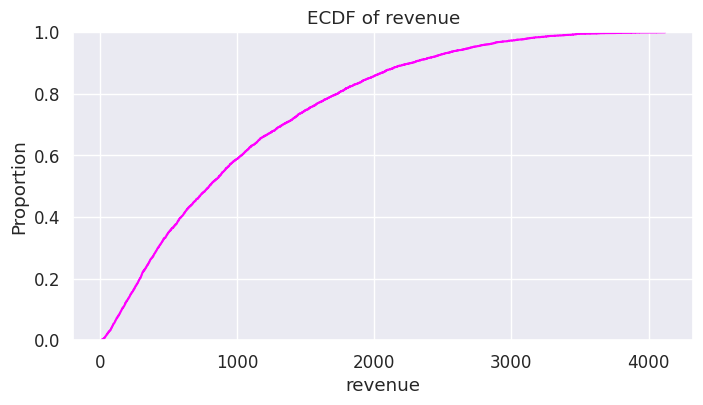

PART 1 COMPLETED


In [11]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

data = df.copy()

# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("="*70)
print("DATASET SHAPE")
print(data.shape)

print("="*70)
print("FIRST 5 ROWS")
print(data.head())

print("="*70)
print("DATA INFO")
print(data.info())

print("="*70)
print("MISSING VALUES")
print(data.isnull().sum())

print("="*70)
print("STATISTICAL SUMMARY")
print(data.describe(include="all"))

# ==========================================================
# CONVERT DATE COLUMN
# ==========================================================

data["order_date"] = pd.to_datetime(
    data["order_date"],
    errors="coerce"
)

# ==========================================================
# MISSING VALUE HEATMAP
# ==========================================================

plt.figure(figsize=(14,6))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap",fontsize=18)

plt.show()

# ==========================================================
# NUMERICAL & CATEGORICAL COLUMNS
# ==========================================================

num_cols = data.select_dtypes(include=np.number).columns

cat_cols = data.select_dtypes(include="object").columns

print("\nNumerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

# ==========================================================
# HISTOGRAMS
# ==========================================================

colors = [
"red","blue","green","orange",
"purple","brown","cyan",
"magenta","gold","pink",
"olive","teal"
]

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.histplot(
        data[col],
        bins=30,
        kde=True,
        color=colors[i%len(colors)]
    )

    plt.title(f"Histogram of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

# ==========================================================
# KDE PLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data[col],
        fill=True,
        color=colors[i%len(colors)]
    )

    plt.title(f"KDE Plot of {col}")

    plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=data[col],
        color=colors[i%len(colors)]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

# ==========================================================
# ECDF PLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.ecdfplot(
        data[col],
        color=colors[i%len(colors)]
    )

    plt.title(f"ECDF of {col}")

    plt.show()

print("="*70)
print("PART 1 COMPLETED")
print("="*70)

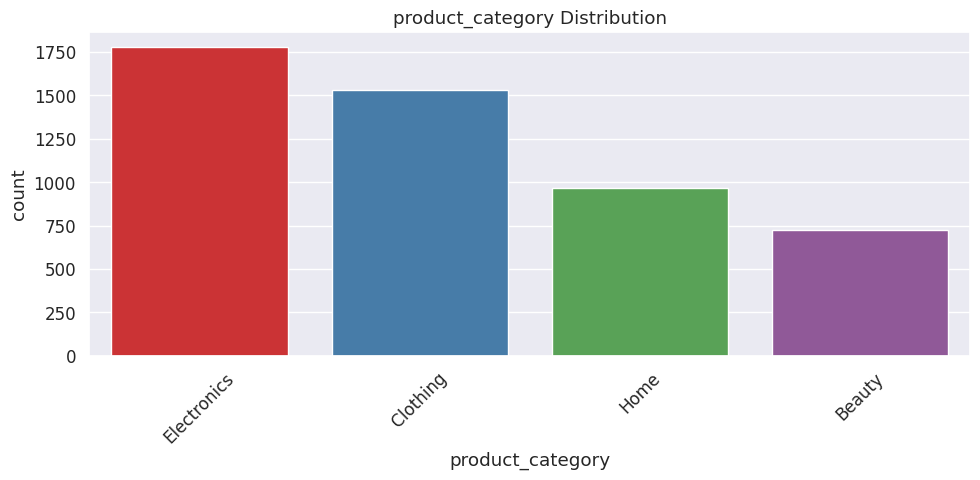

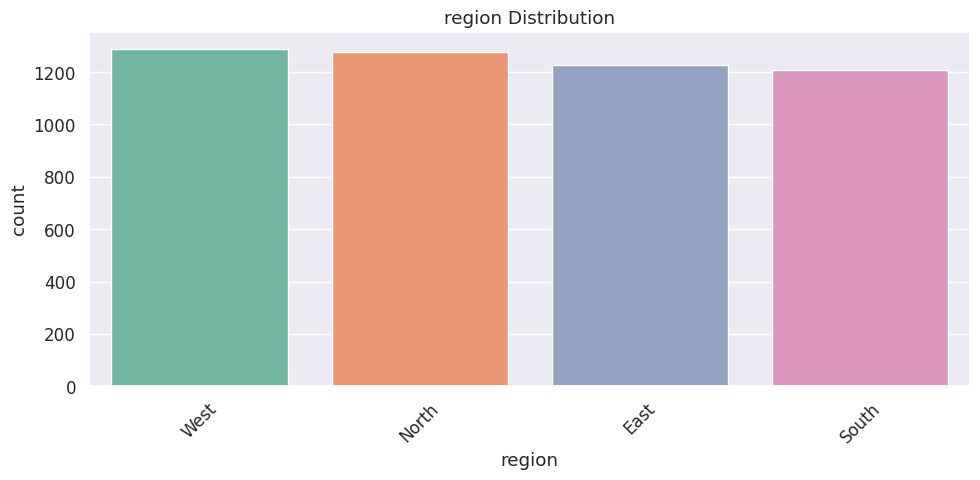

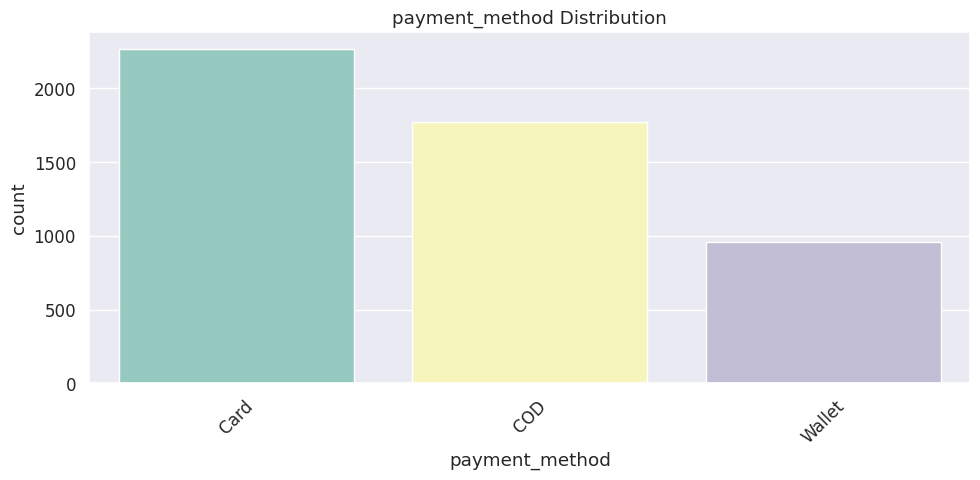

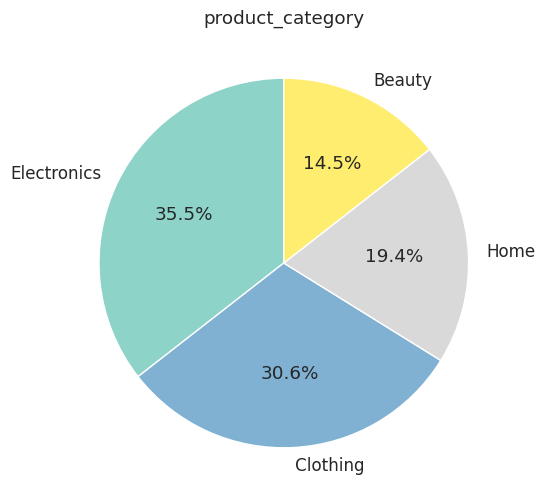

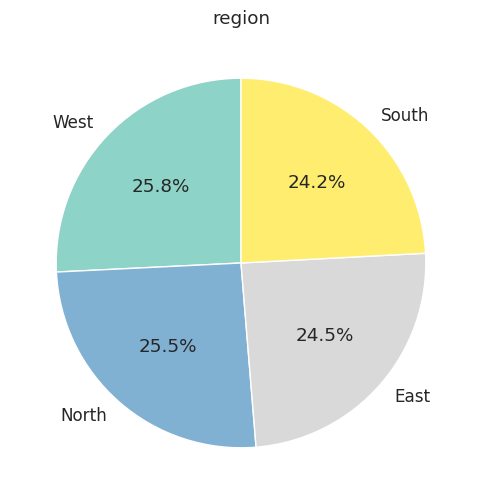

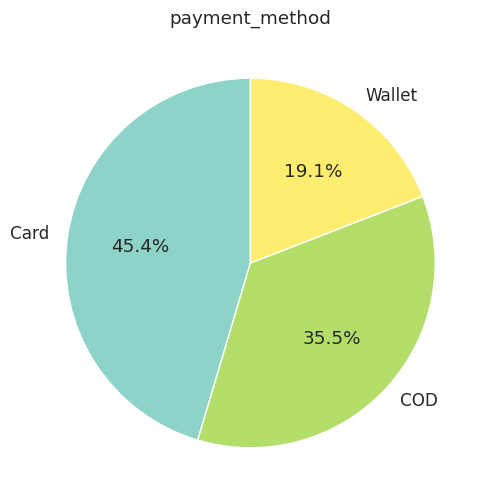

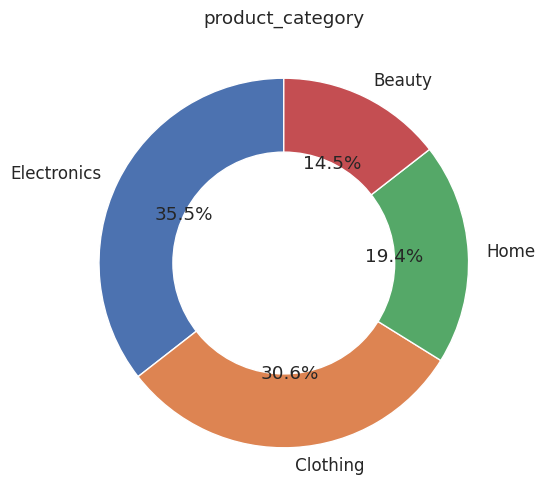

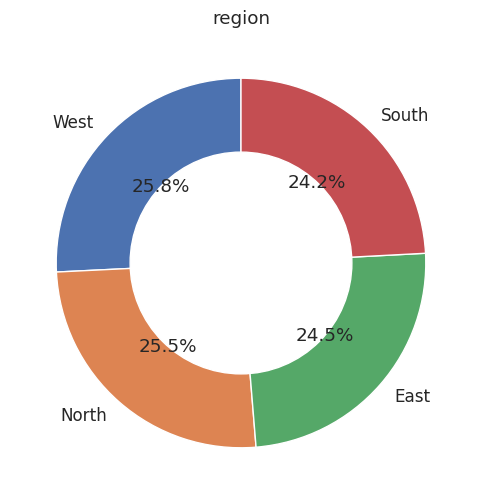

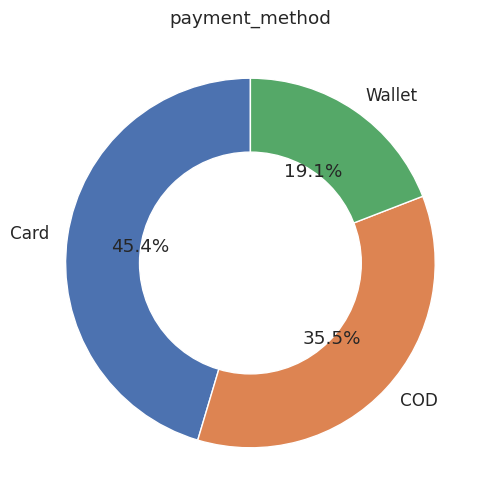

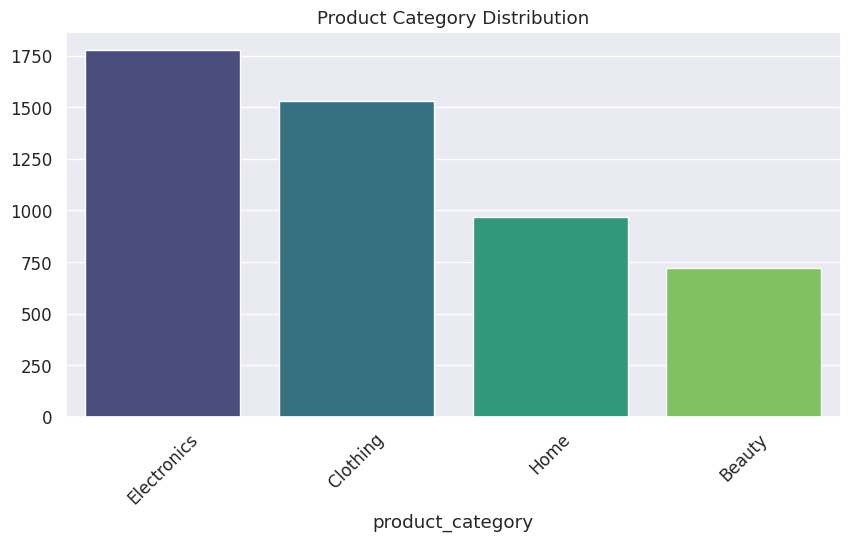

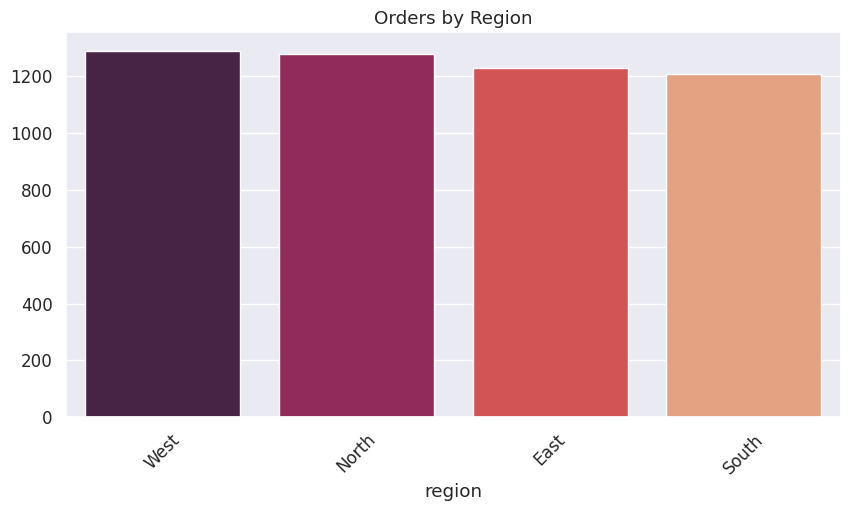

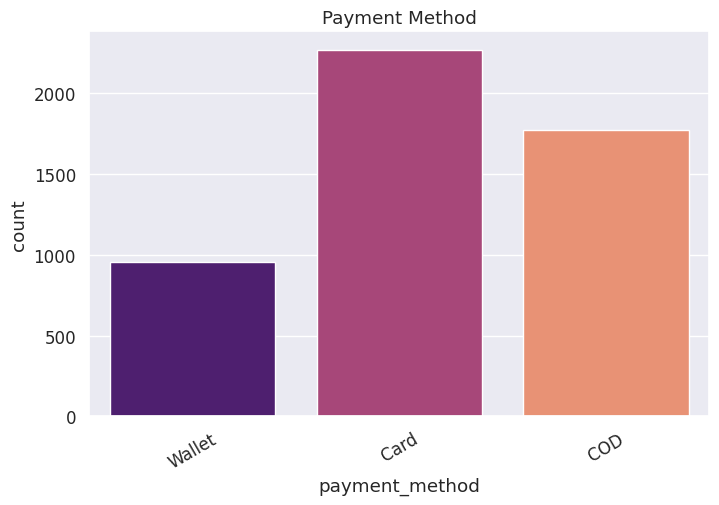

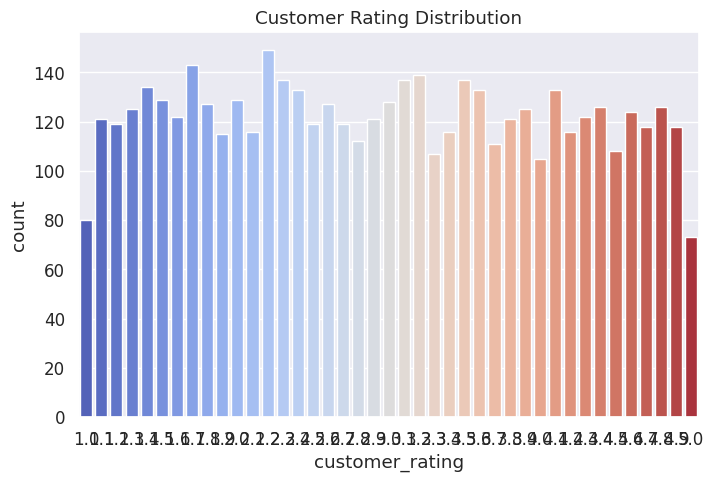

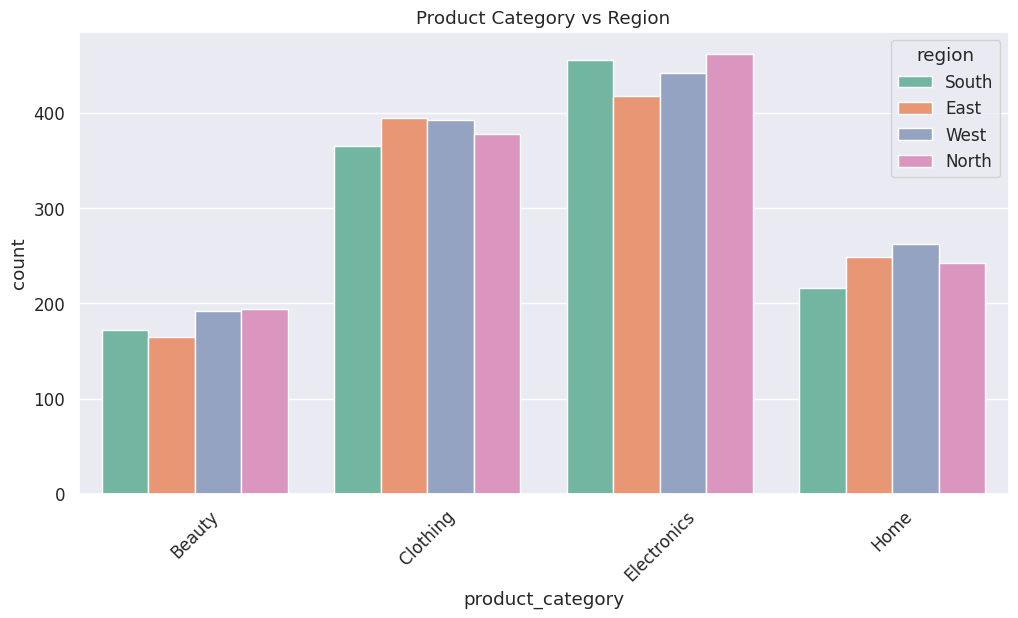

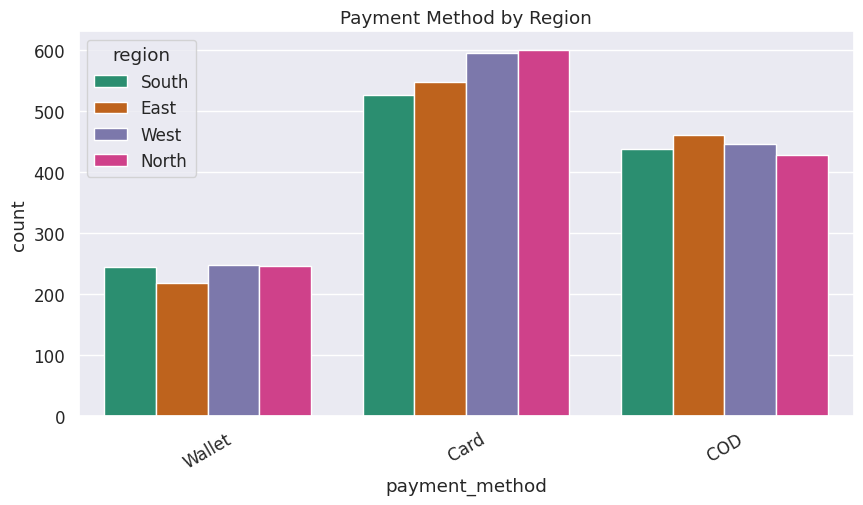

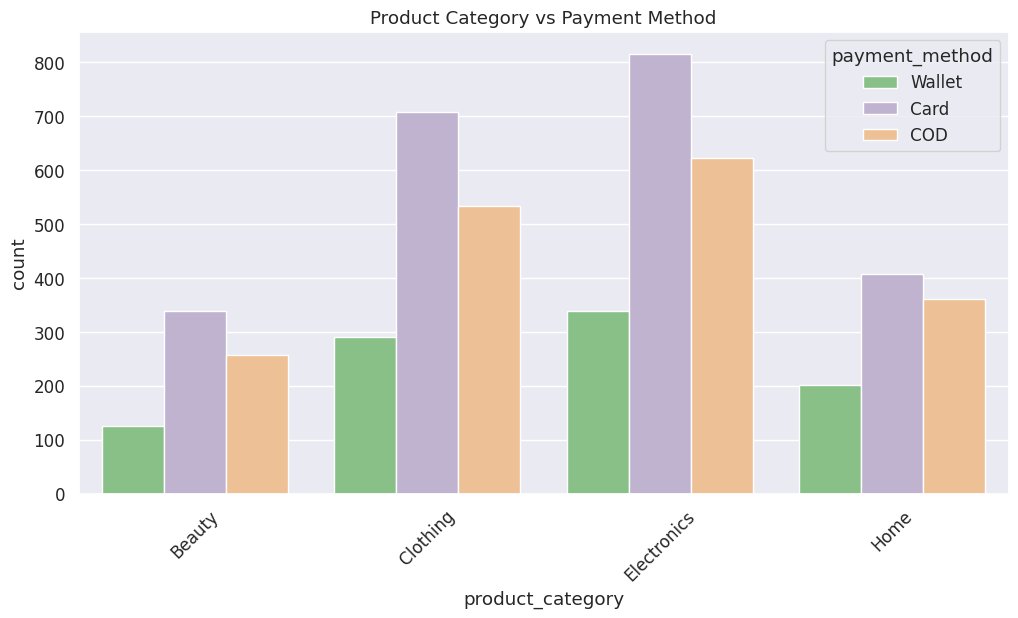

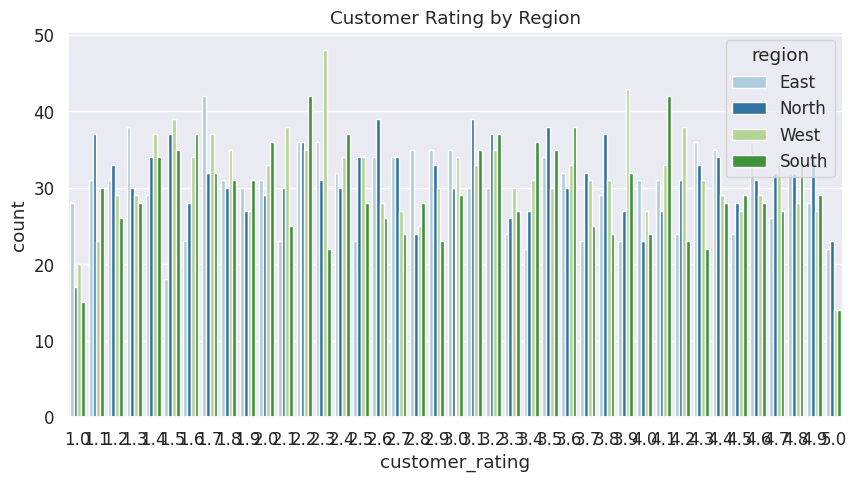

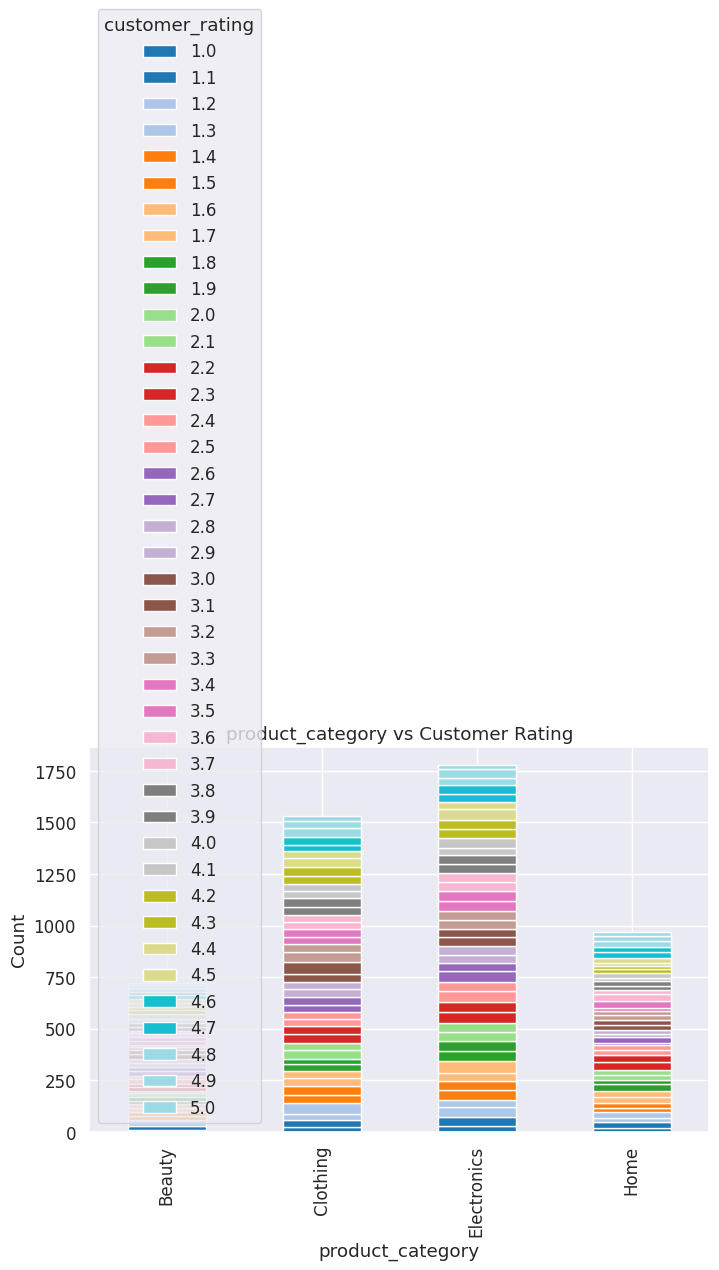

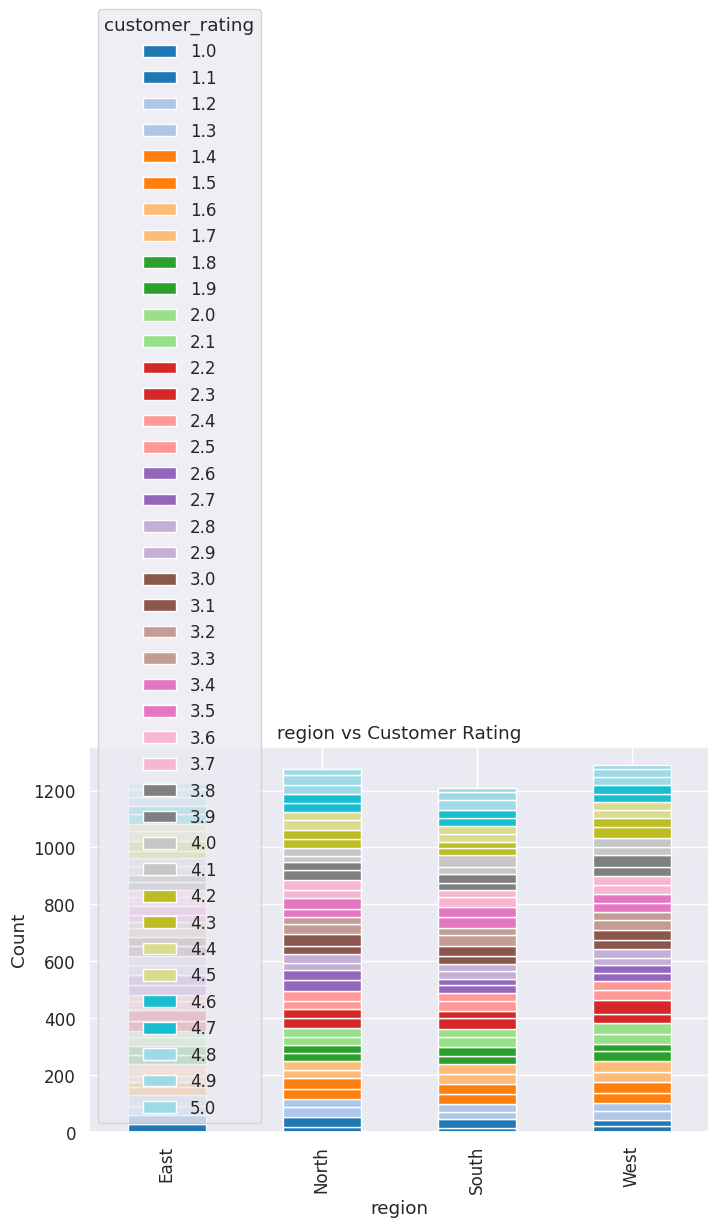

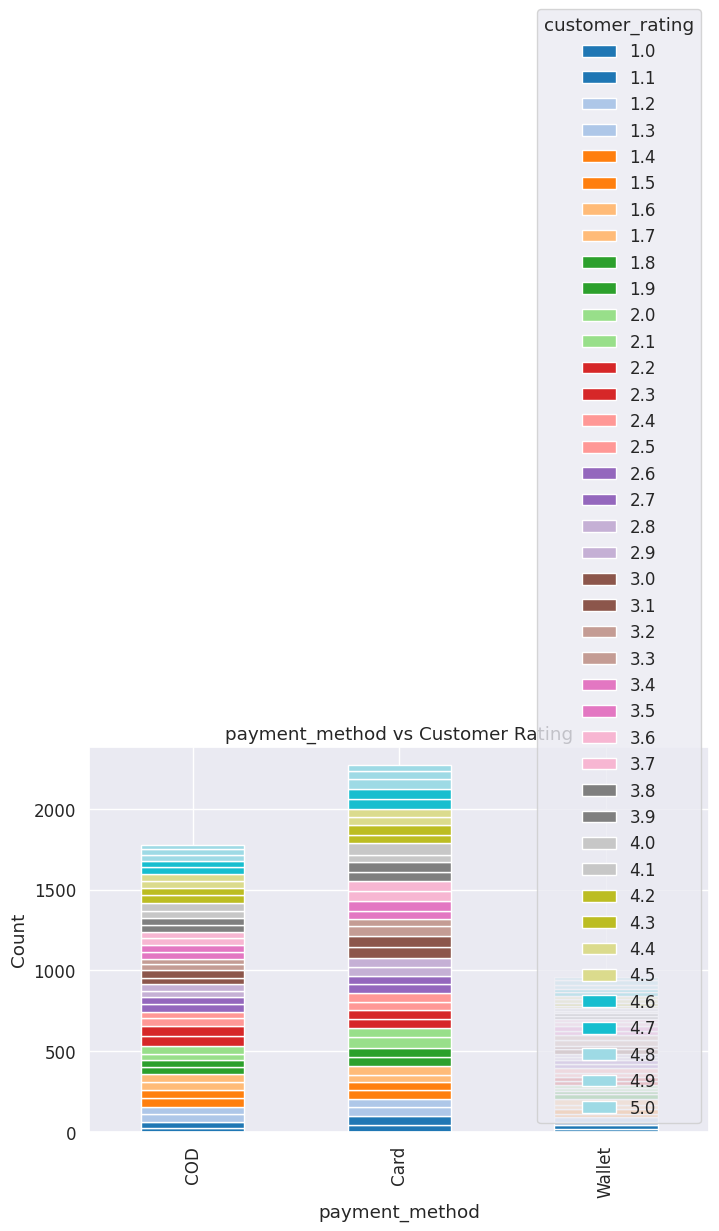

PART 2 COMPLETED


In [12]:
# ==========================================================
# PART 2 : CATEGORICAL VISUALIZATIONS
# ==========================================================

palettes = [
    "Set1","Set2","Set3","Accent","Dark2",
    "Paired","Pastel1","Pastel2","rocket",
    "mako","crest","flare","viridis",
    "Spectral","coolwarm"
]

# ==========================================================
# COUNTPLOTS
# ==========================================================

for i,col in enumerate(cat_cols):

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=data,
        x=col,
        order=data[col].value_counts().index,
        palette=palettes[i%len(palettes)]
    )

    plt.title(col + " Distribution")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# ==========================================================
# PIE CHARTS
# ==========================================================

pie_cols = [
    "product_category",
    "region",
    "payment_method"
]

for col in pie_cols:

    if col in data.columns:

        plt.figure(figsize=(6,6))

        data[col].value_counts().plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90,
            cmap="Set3"
        )

        plt.ylabel("")

        plt.title(col)

        plt.show()

# ==========================================================
# DONUT CHARTS
# ==========================================================

for col in pie_cols:

    if col in data.columns:

        counts = data[col].value_counts()

        fig, ax = plt.subplots(figsize=(6,6))

        ax.pie(
            counts,
            labels=counts.index,
            autopct="%1.1f%%",
            startangle=90
        )

        centre = plt.Circle((0,0),0.60,fc="white")

        fig.gca().add_artist(centre)

        plt.title(col)

        plt.show()

# ==========================================================
# PRODUCT CATEGORY
# ==========================================================

plt.figure(figsize=(10,5))

category = data["product_category"].value_counts()

sns.barplot(
    x=category.index,
    y=category.values,
    palette="viridis"
)

plt.title("Product Category Distribution")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# REGION ANALYSIS
# ==========================================================

plt.figure(figsize=(10,5))

region = data["region"].value_counts()

sns.barplot(
    x=region.index,
    y=region.values,
    palette="rocket"
)

plt.title("Orders by Region")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# PAYMENT METHOD
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="payment_method",
    palette="magma"
)

plt.title("Payment Method")

plt.xticks(rotation=30)

plt.show()

# ==========================================================
# CUSTOMER RATING DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="customer_rating",
    palette="coolwarm"
)

plt.title("Customer Rating Distribution")

plt.show()

# ==========================================================
# CATEGORY VS REGION
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x="product_category",
    hue="region",
    palette="Set2"
)

plt.title("Product Category vs Region")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# PAYMENT METHOD VS REGION
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="payment_method",
    hue="region",
    palette="Dark2"
)

plt.title("Payment Method by Region")

plt.xticks(rotation=30)

plt.show()

# ==========================================================
# PRODUCT CATEGORY VS PAYMENT METHOD
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x="product_category",
    hue="payment_method",
    palette="Accent"
)

plt.title("Product Category vs Payment Method")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# CUSTOMER RATING VS REGION
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="customer_rating",
    hue="region",
    palette="Paired"
)

plt.title("Customer Rating by Region")

plt.show()

# ==========================================================
# STACKED BAR CHARTS
# ==========================================================

features = [
    "product_category",
    "region",
    "payment_method"
]

for col in features:

    table = pd.crosstab(
        data[col],
        data["customer_rating"]
    )

    table.plot(
        kind="bar",
        stacked=True,
        figsize=(8,5),
        colormap="tab20"
    )

    plt.title(col + " vs Customer Rating")

    plt.ylabel("Count")

    plt.tight_layout()

    plt.show()

print("="*70)
print("PART 2 COMPLETED")
print("="*70)

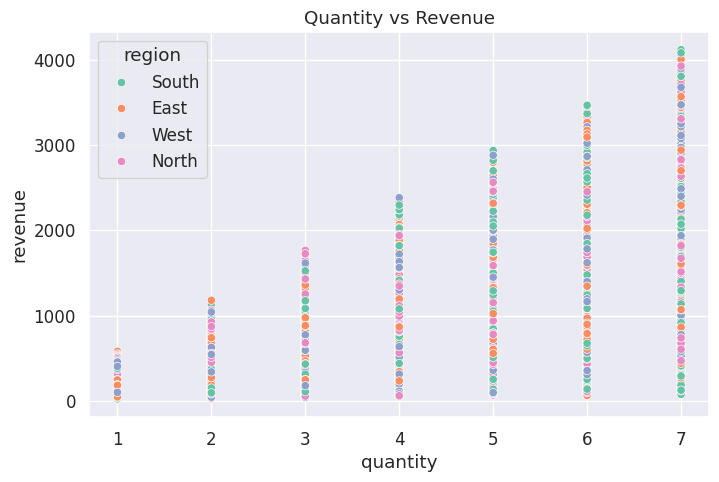

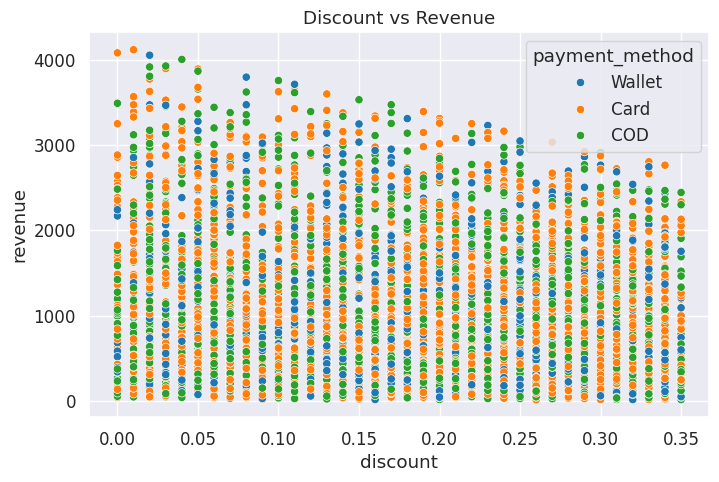

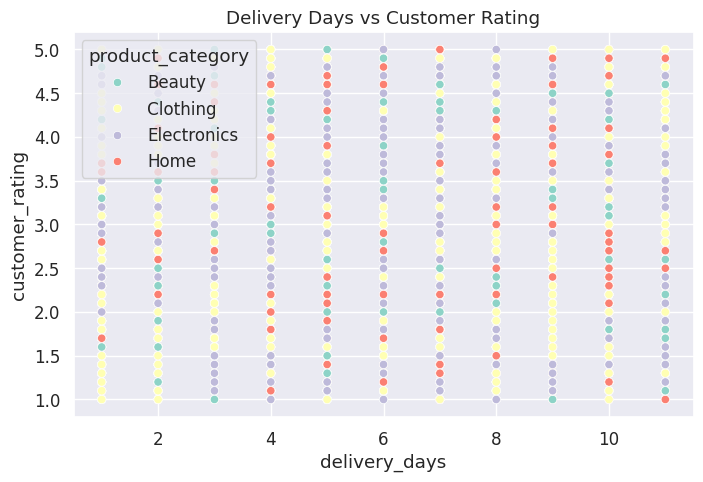

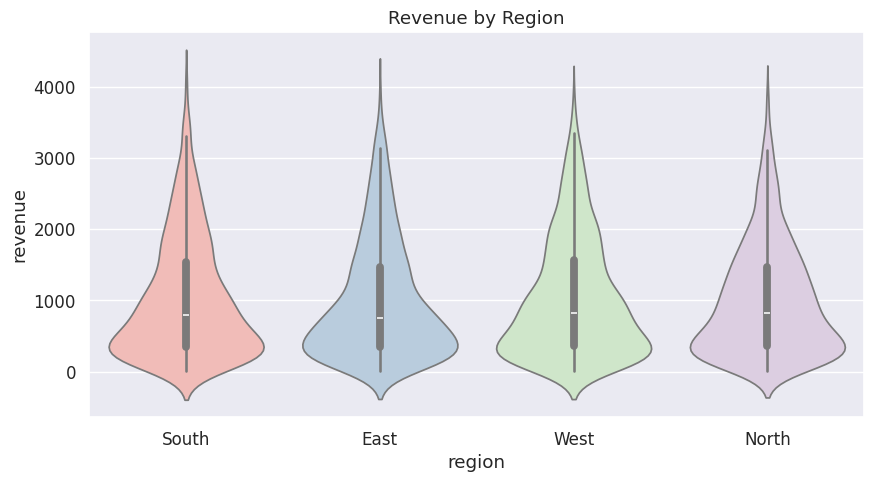

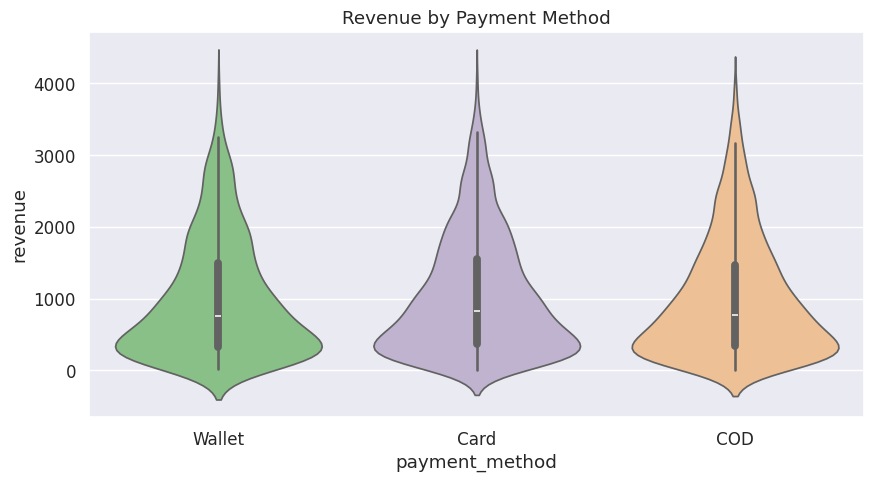

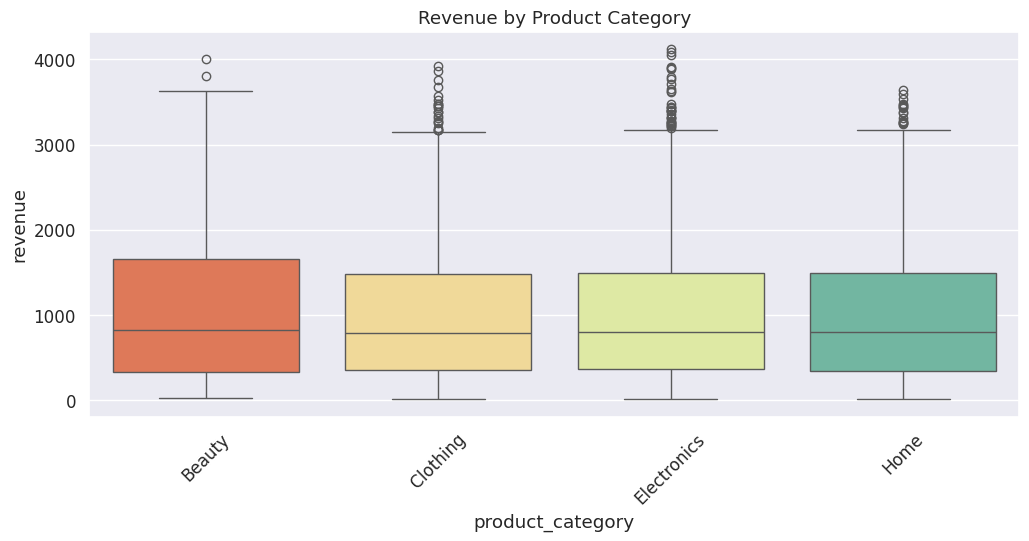

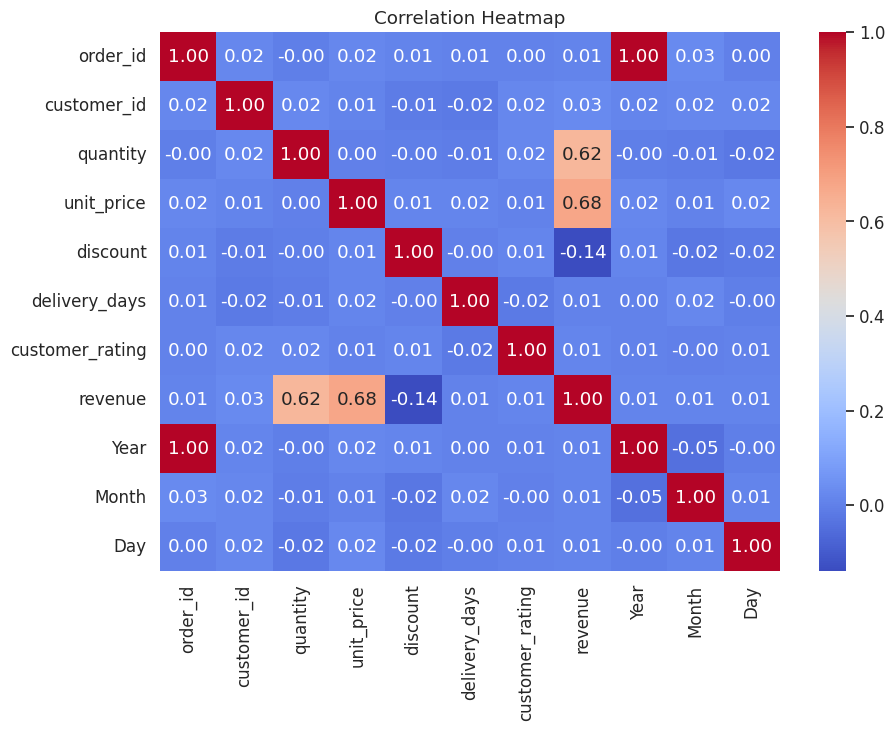

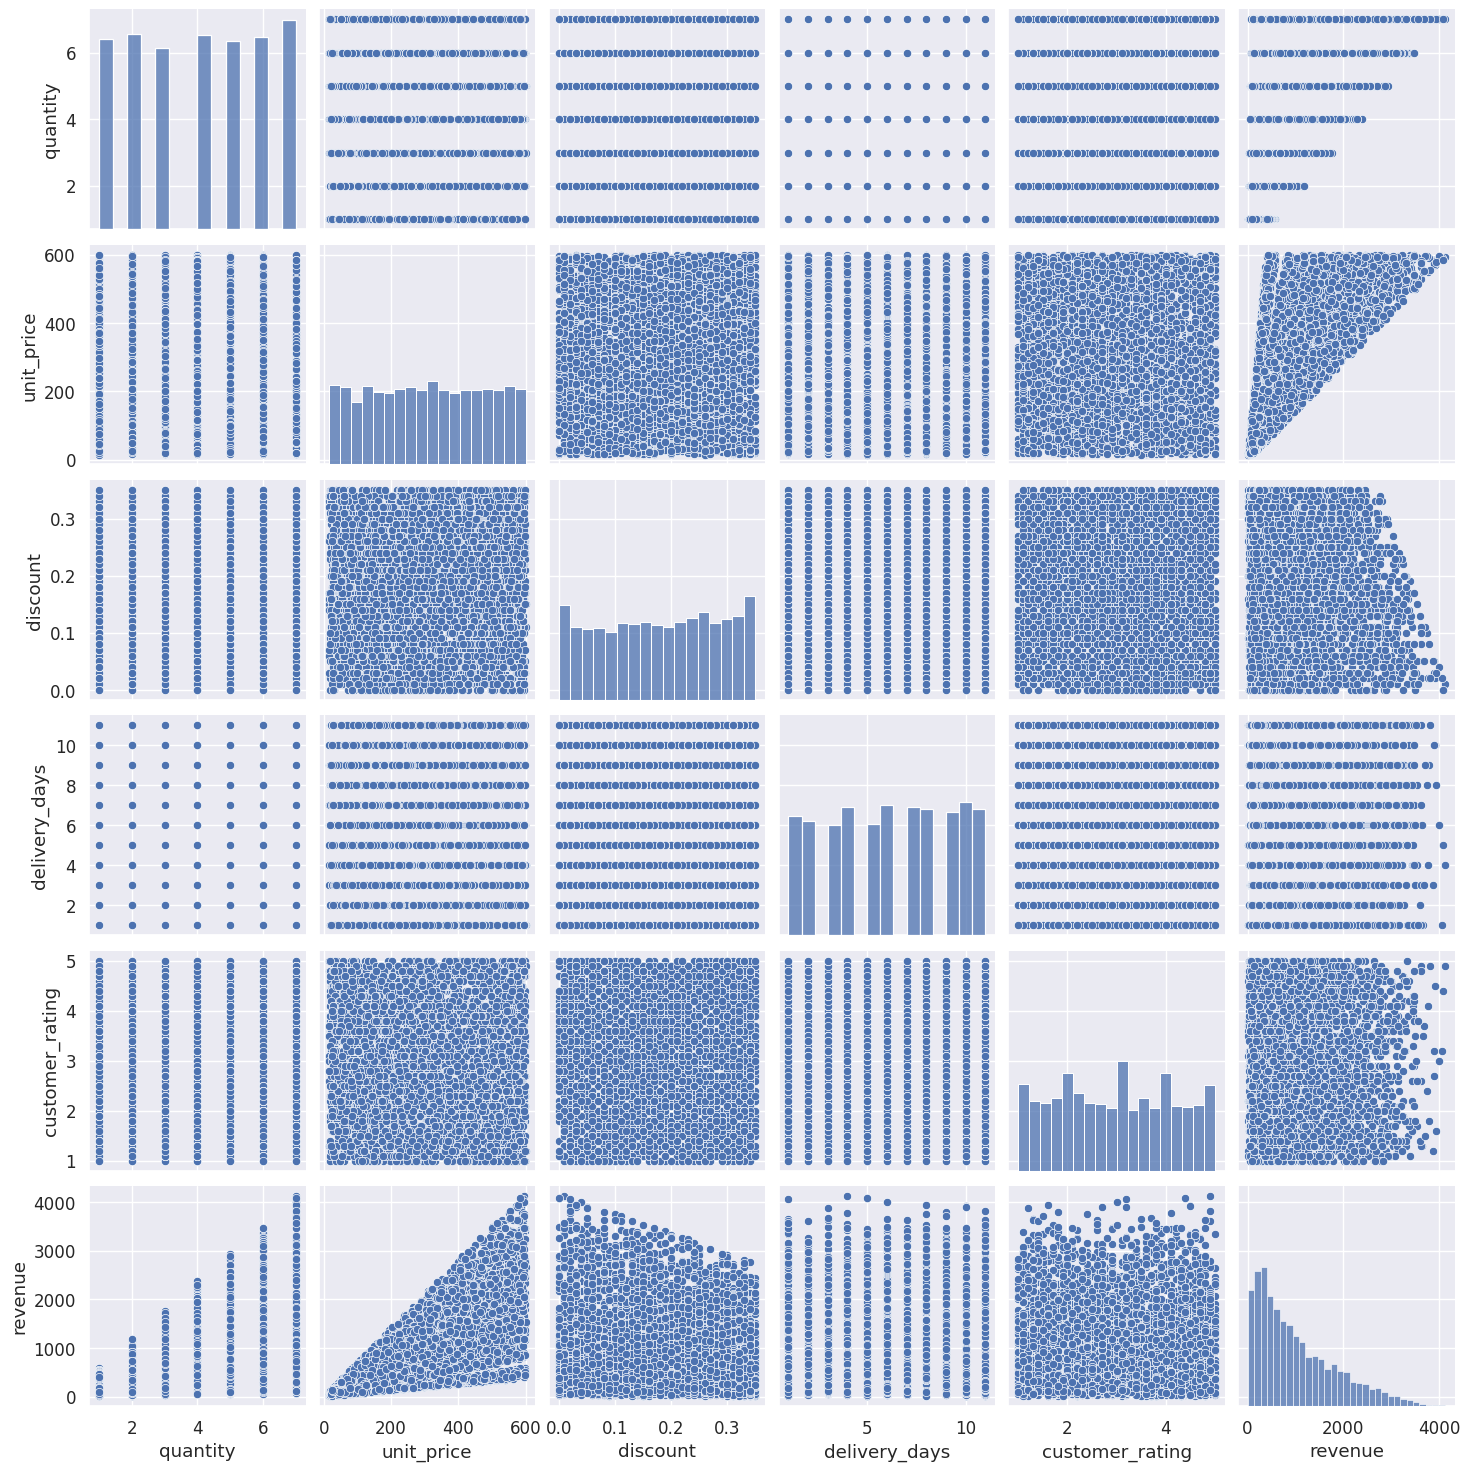

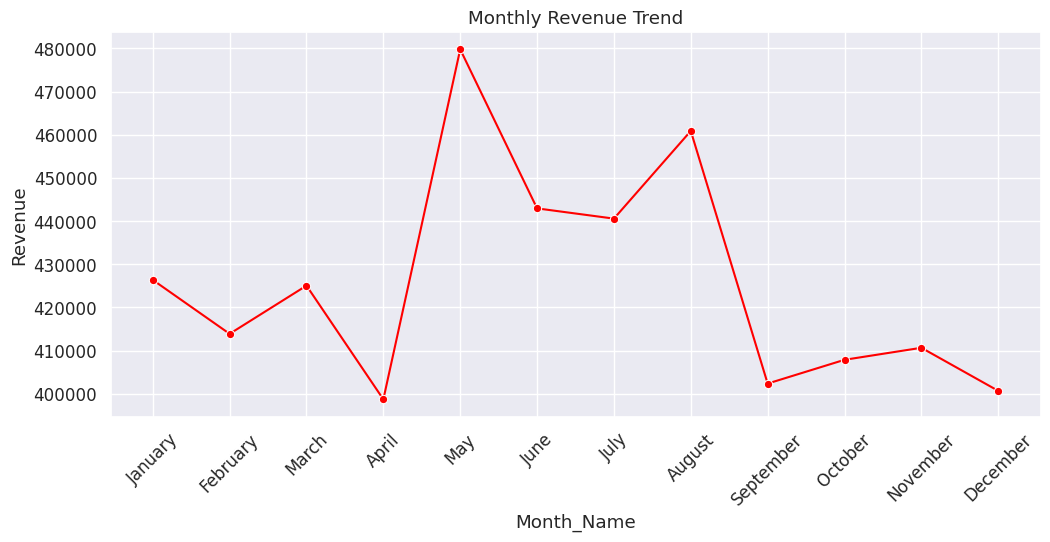

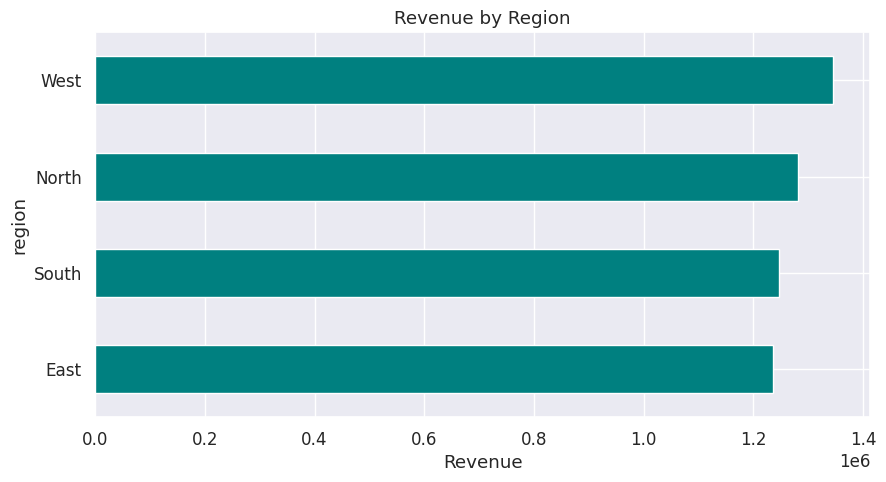

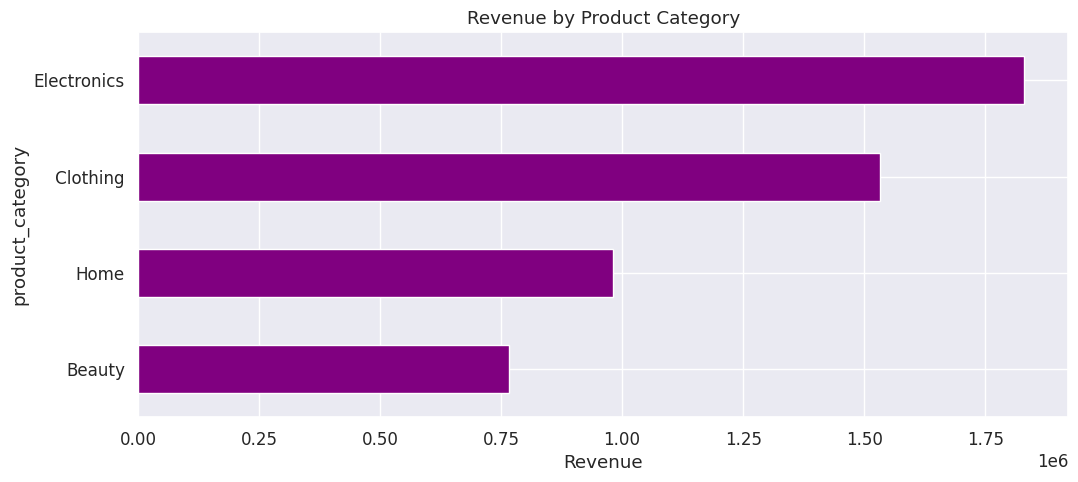

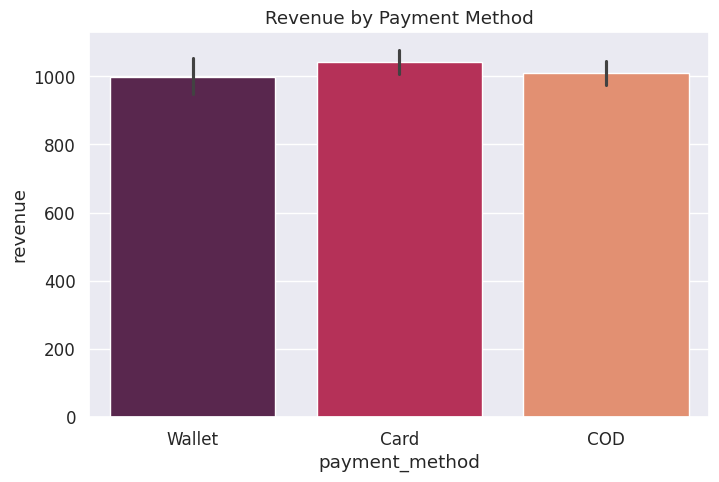

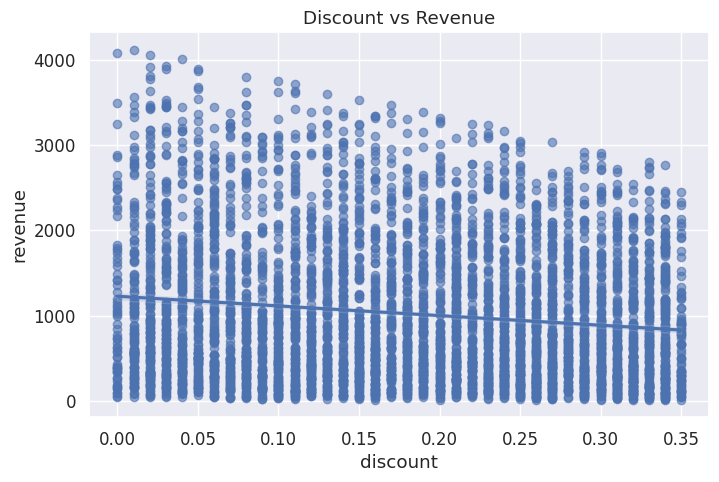

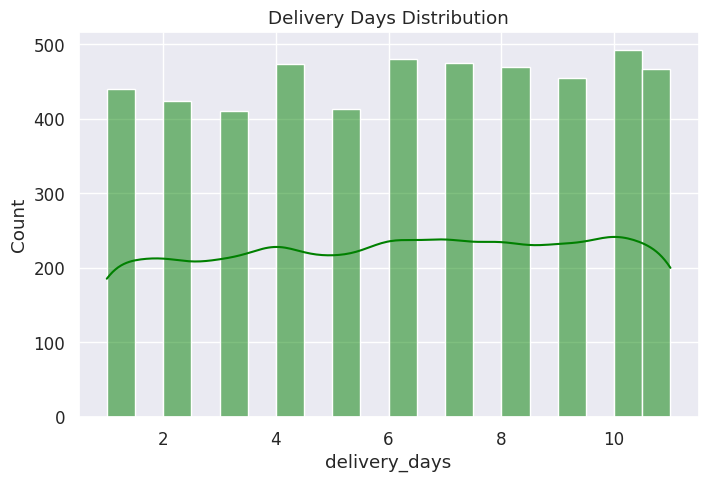

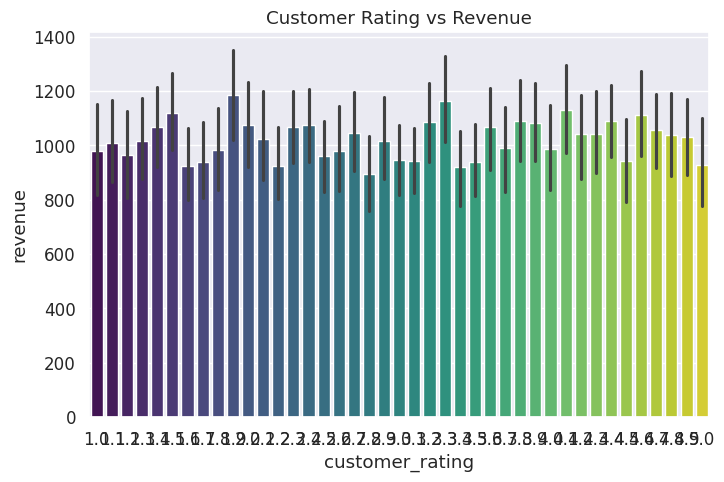

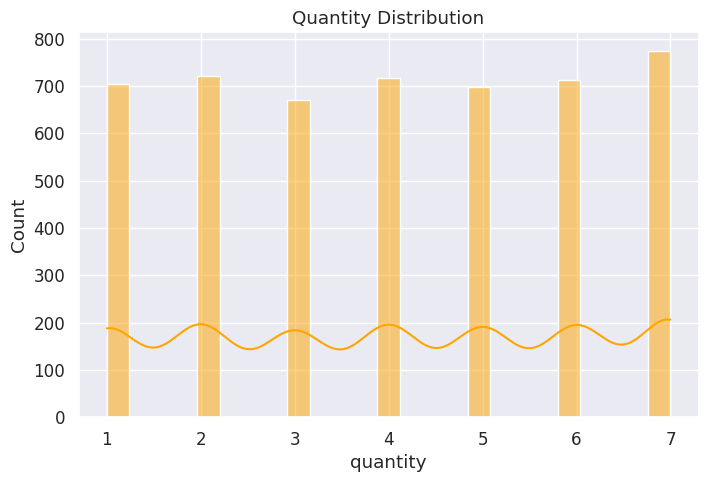

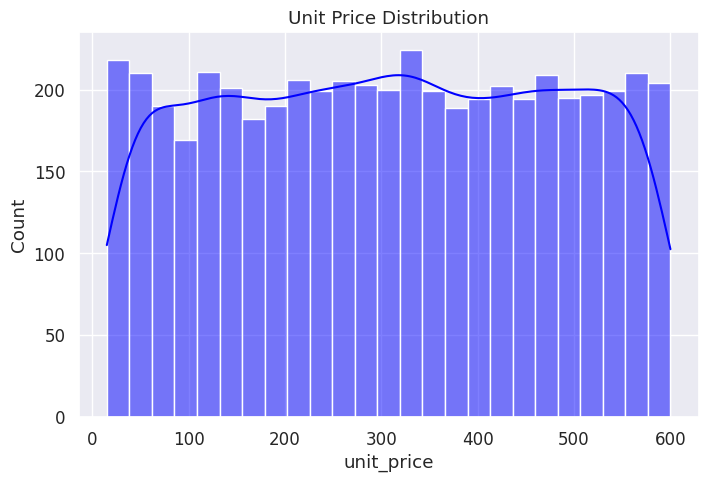

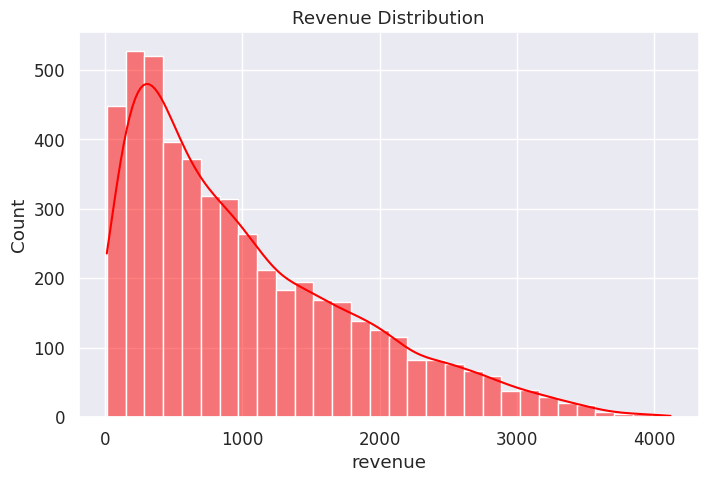

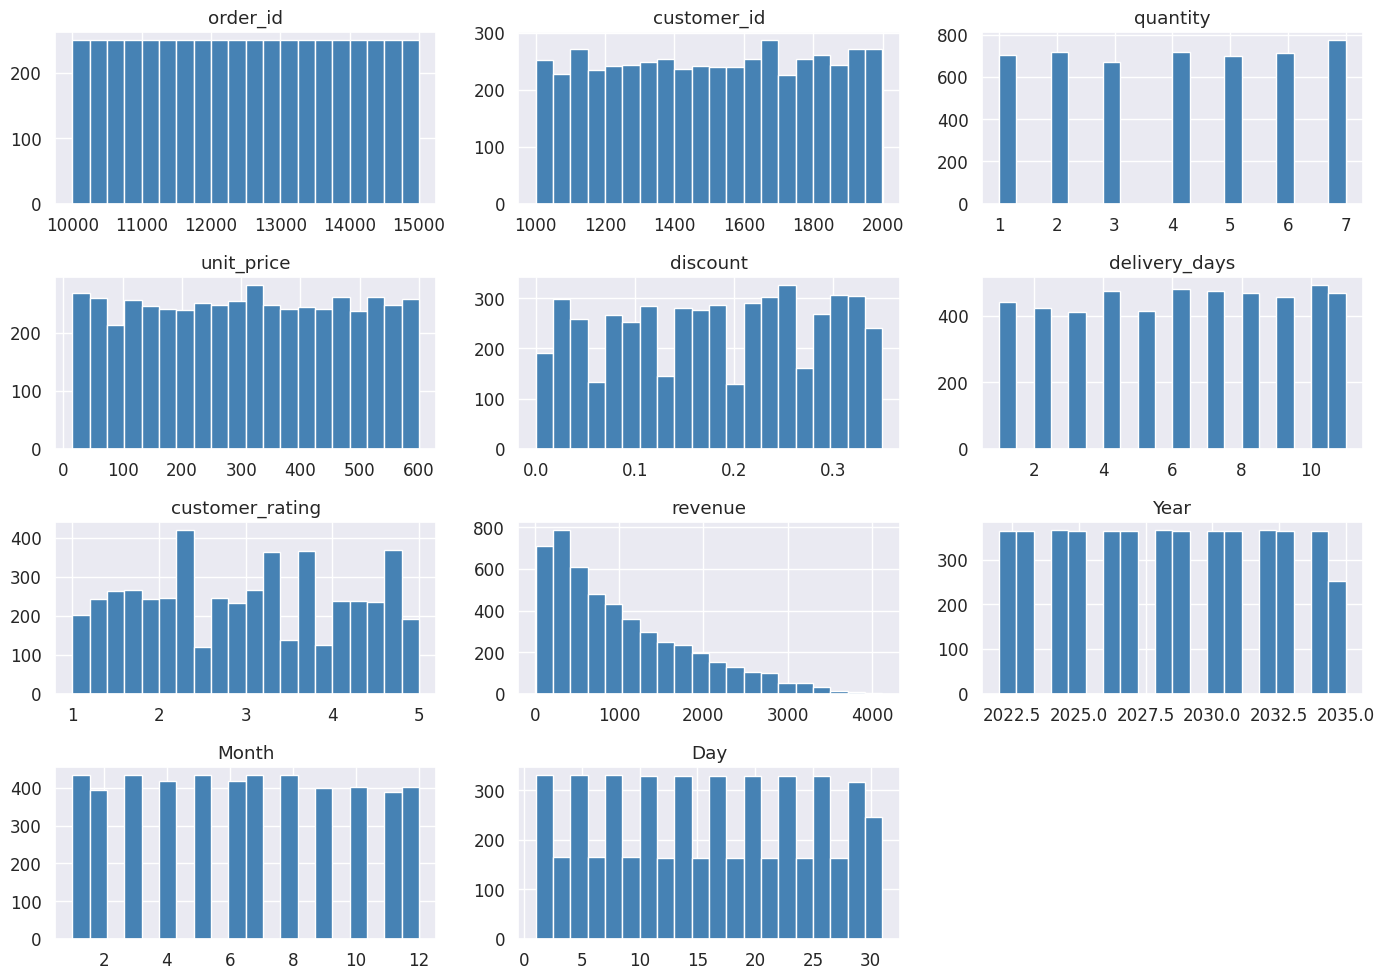

SALES DATASET EDA COMPLETED SUCCESSFULLY


In [13]:
# ==========================================================
# PART 3 : ADVANCED BUSINESS VISUALIZATIONS
# ==========================================================

# Create Date Features
data["Year"] = data["order_date"].dt.year
data["Month"] = data["order_date"].dt.month
data["Month_Name"] = data["order_date"].dt.month_name()
data["Day"] = data["order_date"].dt.day

# ==========================================================
# SCATTER PLOTS
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="quantity",
    y="revenue",
    hue="region",
    palette="Set2"
)

plt.title("Quantity vs Revenue")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="discount",
    y="revenue",
    hue="payment_method",
    palette="tab10"
)

plt.title("Discount vs Revenue")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="delivery_days",
    y="customer_rating",
    hue="product_category",
    palette="Set3"
)

plt.title("Delivery Days vs Customer Rating")

plt.show()

# ==========================================================
# VIOLIN PLOTS
# ==========================================================

plt.figure(figsize=(10,5))

sns.violinplot(
    data=data,
    x="region",
    y="revenue",
    palette="Pastel1"
)

plt.title("Revenue by Region")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(10,5))

sns.violinplot(
    data=data,
    x="payment_method",
    y="revenue",
    palette="Accent"
)

plt.title("Revenue by Payment Method")

plt.show()

# ==========================================================
# BOX PLOTS
# ==========================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=data,
    x="product_category",
    y="revenue",
    palette="Spectral"
)

plt.xticks(rotation=45)

plt.title("Revenue by Product Category")

plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(10,7))

corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

pair_cols = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue"
]

sns.pairplot(data[pair_cols])

plt.show()

# ==========================================================
# MONTHLY REVENUE TREND
# ==========================================================

monthly = data.groupby("Month_Name")["revenue"].sum()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = monthly.reindex(
    [m for m in month_order if m in monthly.index]
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o",
    color="red"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.show()

# ==========================================================
# REGION WISE REVENUE
# ==========================================================

plt.figure(figsize=(10,5))

region_rev = data.groupby("region")["revenue"].sum().sort_values()

region_rev.plot(
    kind="barh",
    color="teal"
)

plt.title("Revenue by Region")

plt.xlabel("Revenue")

plt.show()

# ==========================================================
# CATEGORY WISE REVENUE
# ==========================================================

plt.figure(figsize=(12,5))

cat_rev = data.groupby("product_category")["revenue"].sum().sort_values()

cat_rev.plot(
    kind="barh",
    color="purple"
)

plt.title("Revenue by Product Category")

plt.xlabel("Revenue")

plt.show()

# ==========================================================
# PAYMENT METHOD REVENUE
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=data,
    x="payment_method",
    y="revenue",
    palette="rocket"
)

plt.title("Revenue by Payment Method")

plt.show()

# ==========================================================
# DISCOUNT IMPACT
# ==========================================================

plt.figure(figsize=(8,5))

sns.regplot(
    data=data,
    x="discount",
    y="revenue",
    scatter_kws={"alpha":0.6}
)

plt.title("Discount vs Revenue")

plt.show()

# ==========================================================
# DELIVERY DAYS
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["delivery_days"],
    bins=20,
    kde=True,
    color="green"
)

plt.title("Delivery Days Distribution")

plt.show()

# ==========================================================
# CUSTOMER RATING
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=data,
    x="customer_rating",
    y="revenue",
    palette="viridis"
)

plt.title("Customer Rating vs Revenue")

plt.show()

# ==========================================================
# QUANTITY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["quantity"],
    bins=25,
    kde=True,
    color="orange"
)

plt.title("Quantity Distribution")

plt.show()

# ==========================================================
# UNIT PRICE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["unit_price"],
    bins=25,
    kde=True,
    color="blue"
)

plt.title("Unit Price Distribution")

plt.show()

# ==========================================================
# REVENUE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["revenue"],
    bins=30,
    kde=True,
    color="red"
)

plt.title("Revenue Distribution")

plt.show()

# ==========================================================
# NUMERICAL HISTOGRAM GRID
# ==========================================================

data.select_dtypes(include=np.number).hist(
    figsize=(14,10),
    bins=20,
    color="steelblue"
)

plt.tight_layout()

plt.show()

print("="*70)
print("SALES DATASET EDA COMPLETED SUCCESSFULLY")
print("="*70)

## Features Engineering

In [14]:
# ==========================================================
# SALES DATASET ML PIPELINE - PART 1
# ==========================================================

# ==========================
# IMPORT LIBRARIES
# ==========================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==========================
# ML ALGORITHMS
# ==========================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

# ==========================
# COPY DATASET
# ==========================

data = df.copy()

# ==========================
# DATE FEATURES
# ==========================

data["order_date"] = pd.to_datetime(
    data["order_date"],
    errors="coerce"
)

data["order_year"] = data["order_date"].dt.year
data["order_month"] = data["order_date"].dt.month
data["order_day"] = data["order_date"].dt.day

data.drop(columns=["order_date"], inplace=True)

# ==========================
# DROP ID COLUMNS
# ==========================

drop_cols = [
    "order_id",
    "customer_id"
]

for col in drop_cols:
    if col in data.columns:
        data.drop(columns=col, inplace=True)

# ==========================
# HANDLE MISSING VALUES
# ==========================

for col in data.columns:

    if data[col].dtype == "object":

        data[col].fillna(
            data[col].mode()[0],
            inplace=True
        )

    else:

        data[col].fillna(
            data[col].median(),
            inplace=True
        )

# ==========================
# TARGET
# ==========================

target = "payment_method"

X = data.drop(columns=[target])

y = data[target]

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================
# LABEL ENCODE TARGET
# ==========================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

# ==========================
# LABEL ENCODE FEATURES
# ==========================

encoders = {}

cat_cols = X_train.select_dtypes(include="object").columns

for col in cat_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    X_test[col] = X_test[col].astype(str)

    X_test[col] = X_test[col].apply(
        lambda x:
        le.transform([x])[0]
        if x in le.classes_
        else -1
    )

    encoders[col] = le

# ==========================
# HANDLE MISSING VALUES
# ==========================

imputer = SimpleImputer(strategy="most_frequent")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

# ==========================
# FEATURE SCALING
# ==========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# MODELS
# ==========================

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "AdaBoost":
    AdaBoostClassifier(random_state=42),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC(
        probability=True,
        random_state=42
    ),

    "Naive Bayes":
    GaussianNB()

}

trained_models = {}

results = []

print("="*80)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("="*80)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("Target Classes :")
print(target_encoder.classes_)

PREPROCESSING COMPLETED SUCCESSFULLY
Training Shape : (4000, 11)
Testing Shape  : (1000, 11)
Target Classes :
['COD' 'Card' 'Wallet']



Logistic Regression
Accuracy : 0.452
Precision: 0.3195
Recall   : 0.452
F1 Score : 0.2953

Classification Report

              precision    recall  f1-score   support

         COD       0.32      0.02      0.04       355
        Card       0.46      0.98      0.62       454
      Wallet       0.00      0.00      0.00       191

    accuracy                           0.45      1000
   macro avg       0.26      0.33      0.22      1000
weighted avg       0.32      0.45      0.30      1000



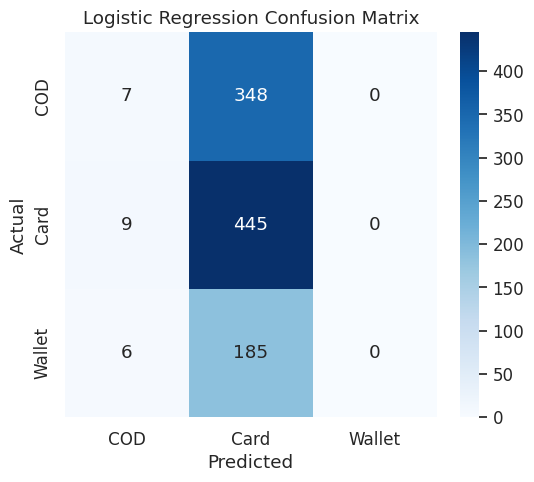

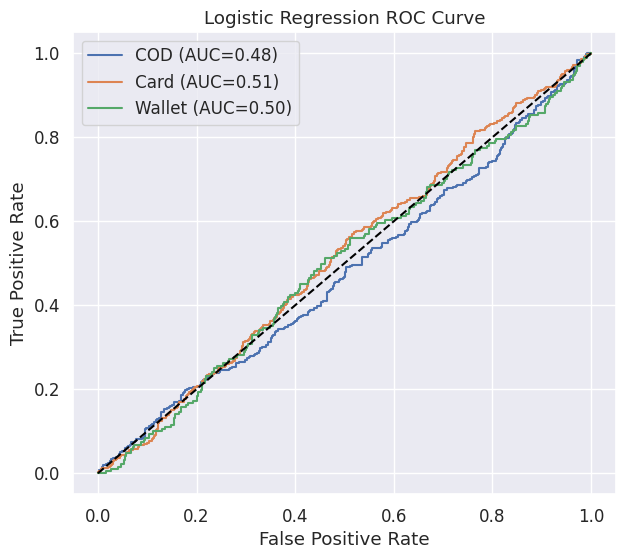


Decision Tree
Accuracy : 0.383
Precision: 0.3867
Recall   : 0.383
F1 Score : 0.3846

Classification Report

              precision    recall  f1-score   support

         COD       0.37      0.39      0.38       355
        Card       0.47      0.45      0.46       454
      Wallet       0.21      0.21      0.21       191

    accuracy                           0.38      1000
   macro avg       0.35      0.35      0.35      1000
weighted avg       0.39      0.38      0.38      1000



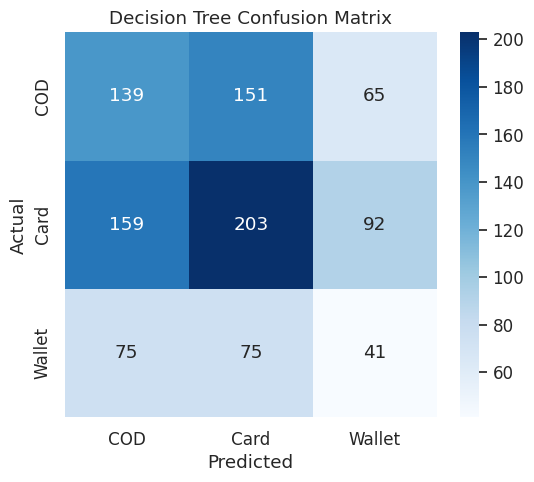

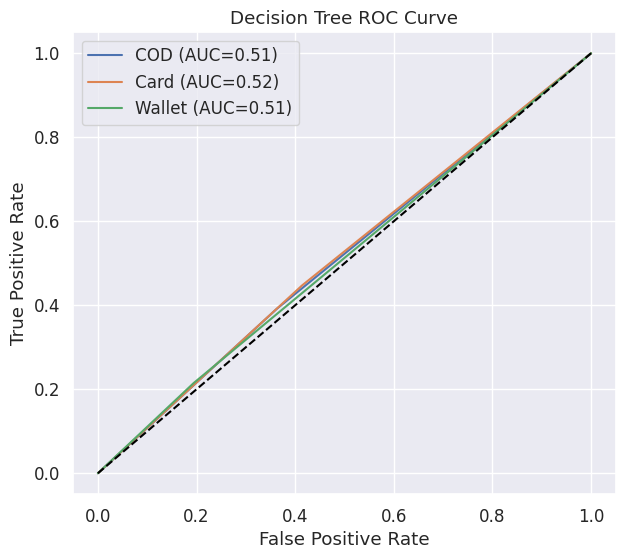


Random Forest
Accuracy : 0.438
Precision: 0.3903
Recall   : 0.438
F1 Score : 0.3807

Classification Report

              precision    recall  f1-score   support

         COD       0.35      0.27      0.30       355
        Card       0.48      0.74      0.58       454
      Wallet       0.26      0.03      0.05       191

    accuracy                           0.44      1000
   macro avg       0.36      0.35      0.31      1000
weighted avg       0.39      0.44      0.38      1000



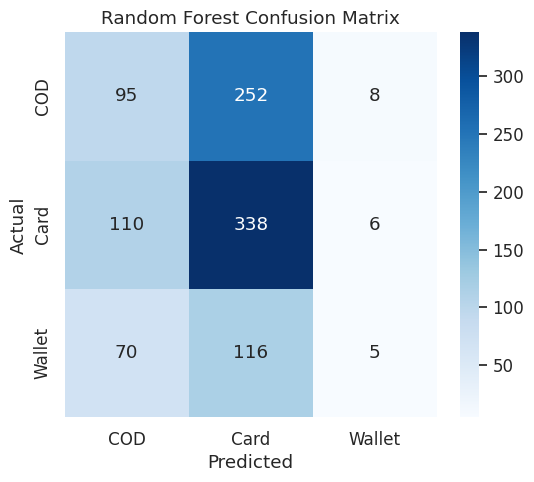

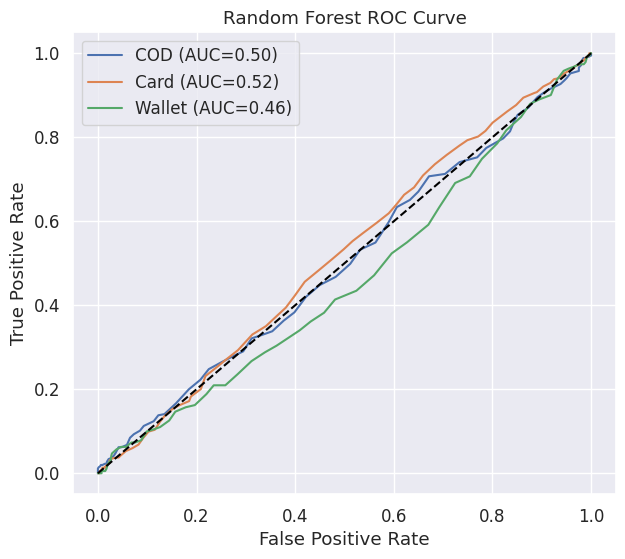


Gradient Boosting
Accuracy : 0.452
Precision: 0.3974
Recall   : 0.452
F1 Score : 0.3742

Classification Report

              precision    recall  f1-score   support

         COD       0.38      0.22      0.28       355
        Card       0.47      0.82      0.60       454
      Wallet       0.25      0.01      0.02       191

    accuracy                           0.45      1000
   macro avg       0.37      0.35      0.30      1000
weighted avg       0.40      0.45      0.37      1000



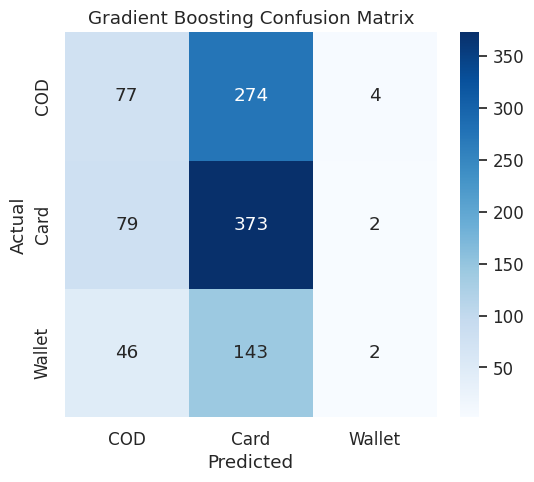

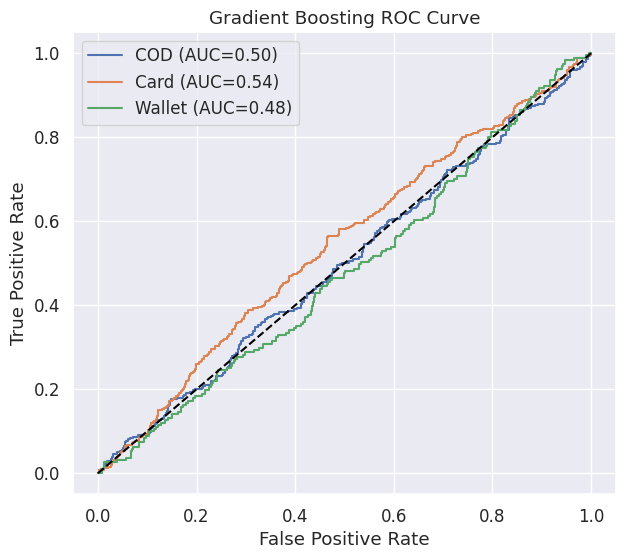


Extra Trees
Accuracy : 0.433
Precision: 0.3635
Recall   : 0.433
F1 Score : 0.3791

Classification Report

              precision    recall  f1-score   support

         COD       0.38      0.30      0.34       355
        Card       0.47      0.71      0.56       454
      Wallet       0.09      0.01      0.02       191

    accuracy                           0.43      1000
   macro avg       0.31      0.34      0.31      1000
weighted avg       0.36      0.43      0.38      1000



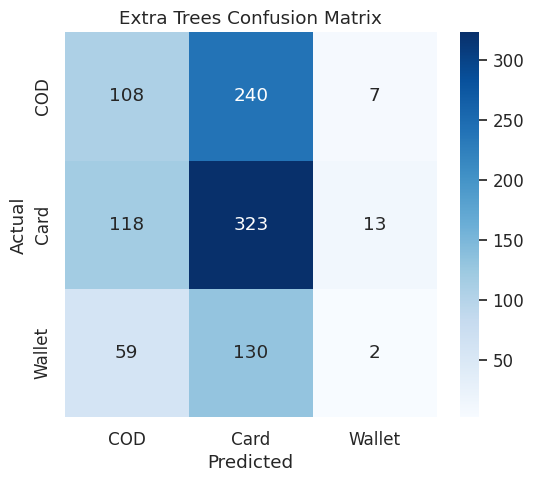

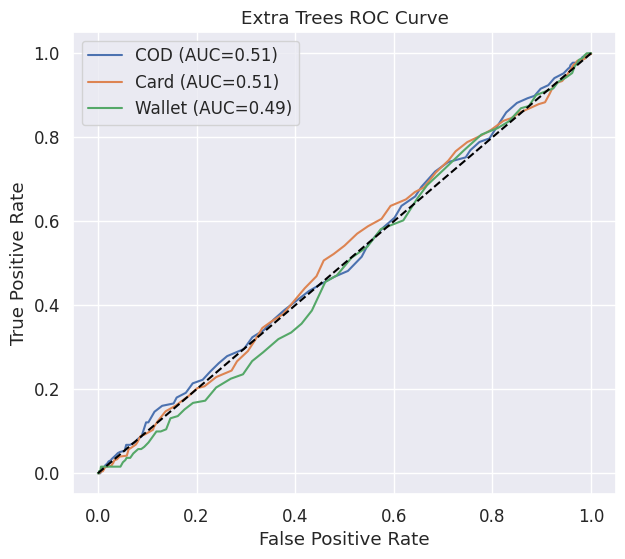


AdaBoost
Accuracy : 0.448
Precision: 0.3445
Recall   : 0.448
F1 Score : 0.3452

Classification Report

              precision    recall  f1-score   support

         COD       0.39      0.14      0.20       355
        Card       0.46      0.88      0.60       454
      Wallet       0.00      0.00      0.00       191

    accuracy                           0.45      1000
   macro avg       0.28      0.34      0.27      1000
weighted avg       0.34      0.45      0.35      1000



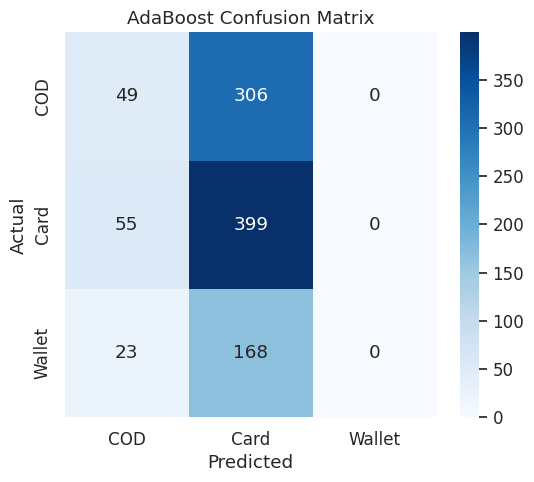

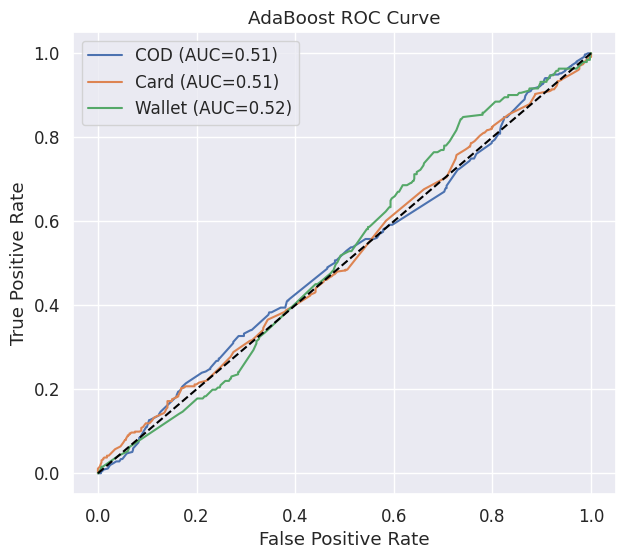


KNN
Accuracy : 0.393
Precision: 0.362
Recall   : 0.393
F1 Score : 0.3692

Classification Report

              precision    recall  f1-score   support

         COD       0.35      0.43      0.39       355
        Card       0.45      0.51      0.48       454
      Wallet       0.16      0.05      0.07       191

    accuracy                           0.39      1000
   macro avg       0.32      0.33      0.31      1000
weighted avg       0.36      0.39      0.37      1000



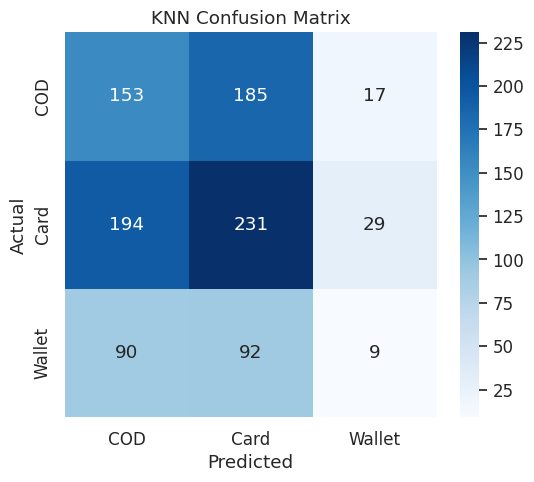

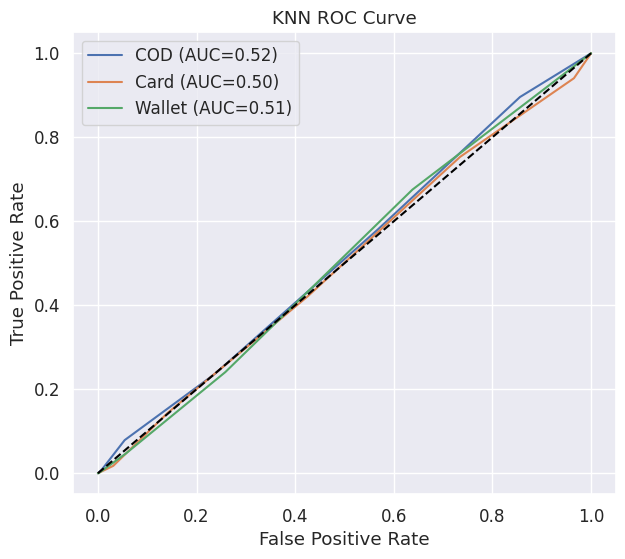


SVM
Accuracy : 0.445
Precision: 0.3404
Recall   : 0.445
F1 Score : 0.3487

Classification Report

              precision    recall  f1-score   support

         COD       0.37      0.15      0.22       355
        Card       0.46      0.86      0.60       454
      Wallet       0.00      0.00      0.00       191

    accuracy                           0.45      1000
   macro avg       0.28      0.34      0.27      1000
weighted avg       0.34      0.45      0.35      1000



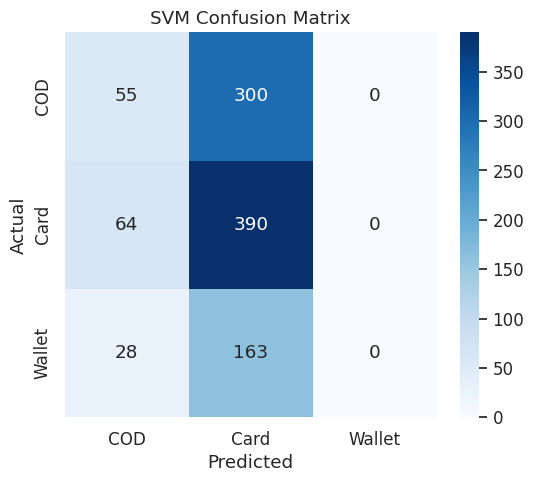

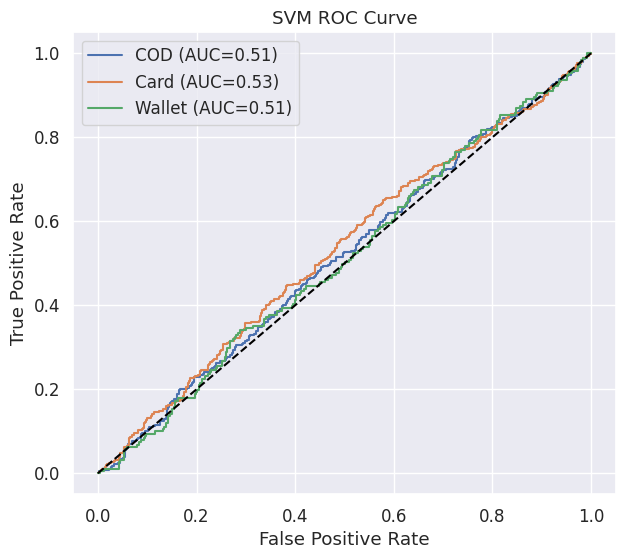


Naive Bayes
Accuracy : 0.458
Precision: 0.3554
Recall   : 0.458
F1 Score : 0.3336

Classification Report

              precision    recall  f1-score   support

         COD       0.41      0.09      0.15       355
        Card       0.46      0.94      0.62       454
      Wallet       0.00      0.00      0.00       191

    accuracy                           0.46      1000
   macro avg       0.29      0.34      0.26      1000
weighted avg       0.36      0.46      0.33      1000



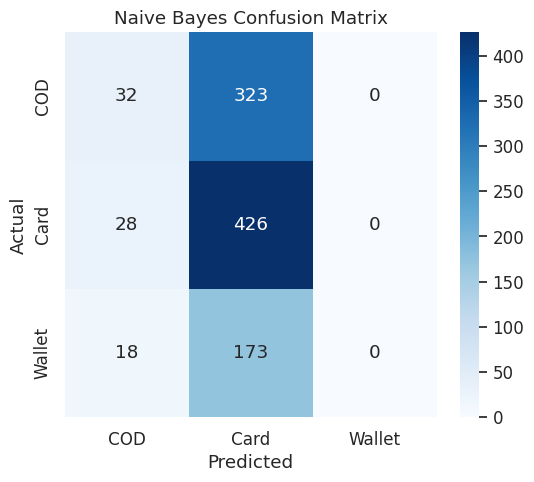

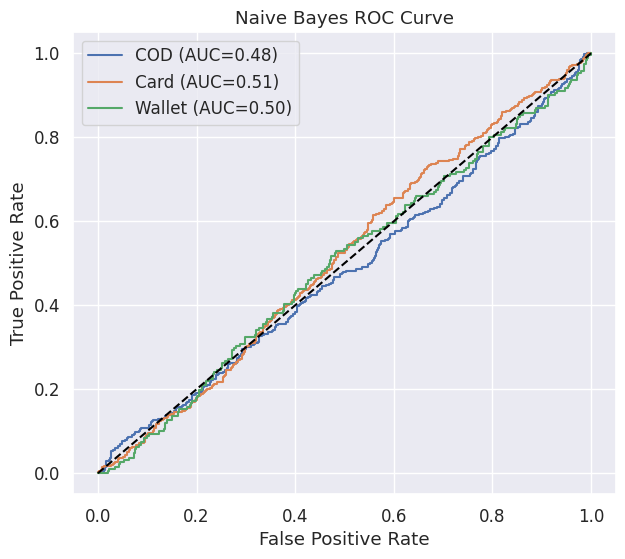



MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score
8          Naive Bayes     0.458   0.355407   0.458  0.333582
0  Logistic Regression     0.452   0.319529   0.452  0.295348
3    Gradient Boosting     0.452   0.397429   0.452  0.374244
5             AdaBoost     0.448   0.344467   0.448  0.345194
7                  SVM     0.445   0.340396   0.445  0.348730
2        Random Forest     0.438   0.390254   0.438  0.380731
4          Extra Trees     0.433   0.363495   0.433  0.379096
6                  KNN     0.393   0.361990   0.393  0.369168
1        Decision Tree     0.383   0.386673   0.383  0.384573


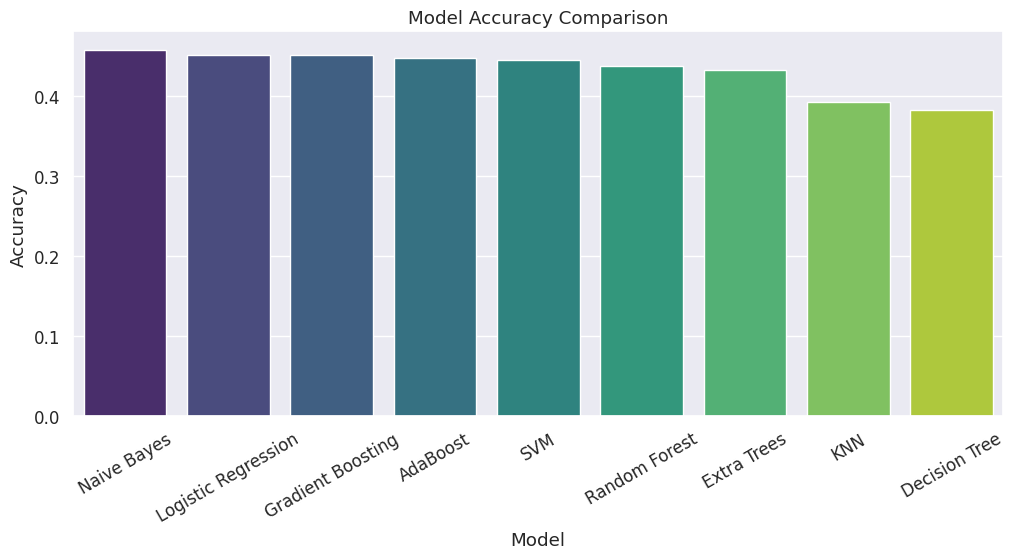

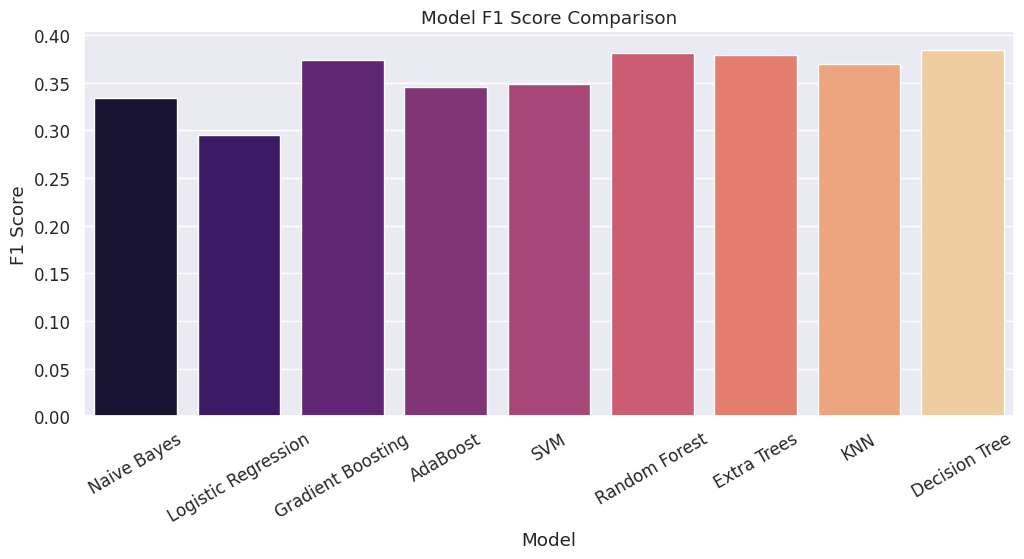

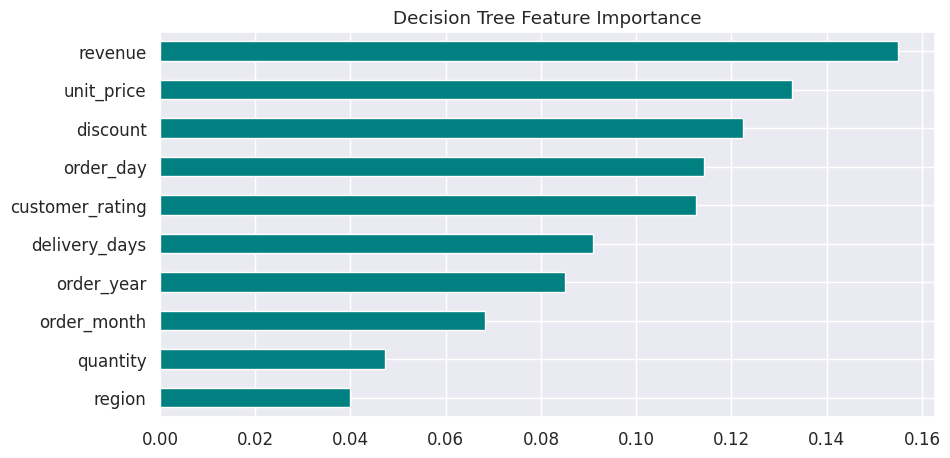

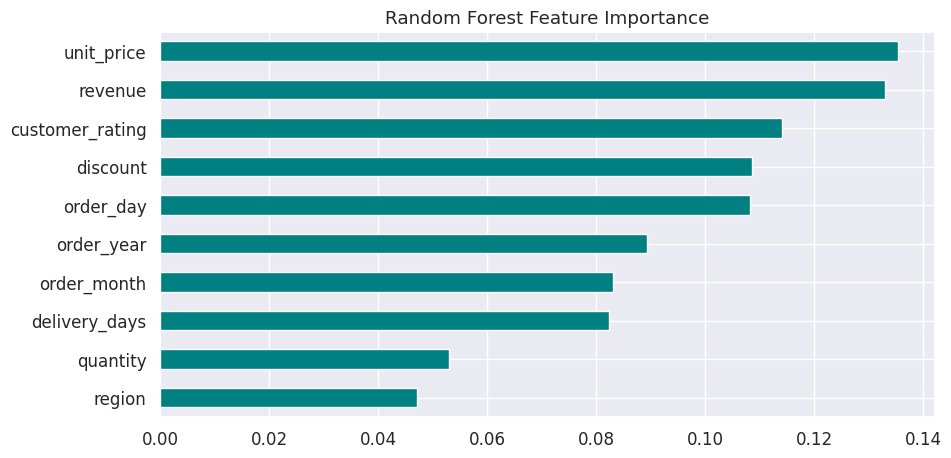

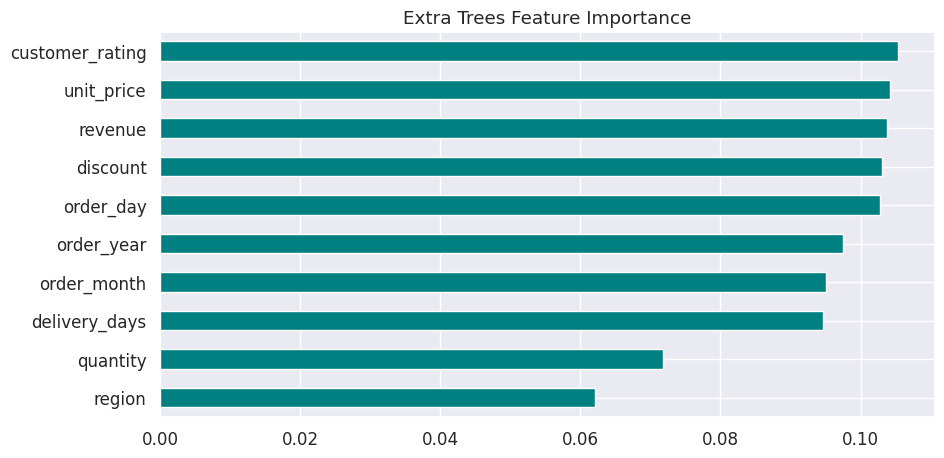



BEST MODEL
Model        Naive Bayes
Accuracy           0.458
Precision       0.355407
Recall             0.458
F1 Score        0.333582
Name: 8, dtype: object

Best Model : Naive Bayes
Accuracy   : 0.458
Precision  : 0.3554
Recall     : 0.458
F1 Score   : 0.3336

Results saved as Sales_Model_Comparison.csv

MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [15]:
# ==========================================================
# SALES DATASET ML PIPELINE - PART 2
# TRAINING + EVALUATION + ROC CURVE + MODEL COMPARISON
# ==========================================================

results = []

n_classes = len(target_encoder.classes_)

for name, model in models.items():

    print("\n" + "="*80)
    print(name)
    print("="*80)

    # ===============================
    # TRAIN MODEL
    # ===============================

    model.fit(X_train, y_train)

    trained_models[name] = model

    # ===============================
    # PREDICTION
    # ===============================

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    # ===============================
    # CLASSIFICATION REPORT
    # ===============================

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_encoder.classes_,
            zero_division=0
        )
    )

    # ===============================
    # CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        fmt="d",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )

    plt.title(name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ===============================
    # ROC CURVE
    # ===============================

    if hasattr(model, "predict_proba"):

        probability = model.predict_proba(X_test)

        y_binary = label_binarize(
            y_test,
            classes=np.arange(n_classes)
        )

        plt.figure(figsize=(7,6))

        if n_classes == 2:

            fpr, tpr, _ = roc_curve(
                y_binary[:,1],
                probability[:,1]
            )

            roc_auc = auc(fpr,tpr)

            plt.plot(
                fpr,
                tpr,
                label="AUC = %.3f"%roc_auc
            )

        else:

            for i in range(n_classes):

                fpr,tpr,_ = roc_curve(
                    y_binary[:,i],
                    probability[:,i]
                )

                roc_auc = auc(fpr,tpr)

                plt.plot(
                    fpr,
                    tpr,
                    label=f"{target_encoder.classes_[i]} (AUC={roc_auc:.2f})"
                )

        plt.plot(
            [0,1],
            [0,1],
            linestyle="--",
            color="black"
        )

        plt.xlabel("False Positive Rate")

        plt.ylabel("True Positive Rate")

        plt.title(name + " ROC Curve")

        plt.legend()

        plt.grid(True)

        plt.show()

# ==========================================================
# MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

print(results_df)

# ==========================================================
# ACCURACY GRAPH
# ==========================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=30)

plt.title("Model Accuracy Comparison")

plt.show()

# ==========================================================
# F1 SCORE GRAPH
# ==========================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    palette="magma"
)

plt.xticks(rotation=30)

plt.title("Model F1 Score Comparison")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_names = X.columns

for model_name in [
    "Decision Tree",
    "Random Forest",
    "Extra Trees"
]:

    model = trained_models[model_name]

    importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    )

    importance = importance.sort_values(
        ascending=False
    )

    plt.figure(figsize=(10,5))

    importance.head(10).plot(
        kind="barh",
        color="teal"
    )

    plt.title(model_name + " Feature Importance")

    plt.gca().invert_yaxis()

    plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================

best_model = results_df.iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(best_model)

print("\nBest Model :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"],4))
print("Precision  :", round(best_model["Precision"],4))
print("Recall     :", round(best_model["Recall"],4))
print("F1 Score   :", round(best_model["F1 Score"],4))

# ==========================================================
# SAVE RESULTS
# ==========================================================

results_df.to_csv(
    "Sales_Model_Comparison.csv",
    index=False
)

print("\nResults saved as Sales_Model_Comparison.csv")

print("\n" + "="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)

## Thanks..........Please Upvote